In [16]:
# 导入必要的库
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from datetime import datetime

# 设置中文字体和绘图样式
sns.set_style("whitegrid")
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 8)
warnings.filterwarnings('ignore')

## 1. 数据加载

In [2]:
# 加载数据
file_path = "../data/processed/processed_data.csv"
df = pd.read_csv(file_path, encoding='utf-8-sig')

# 转换日期列
df['日期'] = pd.to_datetime(df['日期'])

print(f"数据形状: {df.shape}")
print(f"时间范围: {df['日期'].min()} 到 {df['日期'].max()}")
print(f"总记录数: {len(df)}")
print(f"总天数: {df['日期'].nunique()}")

# 中文列名映射到英文
column_mapping = {
    '时间戳': 'timestamp',
    '日期': 'date',
    '时段': 'time_period',
    '年': 'year',
    '月': 'month',
    '日': 'day',
    '星期': 'weekday',
    '是否周末': 'is_weekend',
    '季度': 'quarter',
    '小时': 'hour',
    '是否高峰时段': 'is_peak_hour',
    '是否夜间': 'is_night',
    '系统负荷-日前': 'system_load_day_ahead',
    '系统负荷-实时': 'system_load_real_time',
    '风电出力-日前': 'wind_power_day_ahead',
    '风电出力-实时': 'wind_power_real_time',
    '光伏出力-日前': 'solar_power_day_ahead',
    '光伏出力-实时': 'solar_power_real_time',
    '水电出力-日前': 'hydro_power_day_ahead',
    '水电出力-实时': 'hydro_power_real_time',
    '联络线计划-日前': 'tie_line_plan_day_ahead',
    '联络线计划-实时': 'tie_line_plan_real_time',
    '非市场化机组出力-日前': 'non_market_unit_power_day_ahead',
    '非市场化机组出力-实时': 'non_market_unit_power_real_time',
    '平均出清价格-日前（元/MWh）': 'clearing_price_day_ahead',
    '平均出清价格-实时（元/MWh）': 'clearing_price_real_time'
}

# 创建英文列名的副本
df_en = df.rename(columns=column_mapping)

# 显示数据基本信息
df.info()

数据形状: (7344, 27)
时间范围: 2024-05-06 00:00:00 到 2025-03-27 00:00:00
总记录数: 7344
总天数: 306
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7344 entries, 0 to 7343
Data columns (total 27 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   时间戳               7344 non-null   object        
 1   日期                7344 non-null   datetime64[ns]
 2   时段                7344 non-null   object        
 3   年                 7344 non-null   int64         
 4   月                 7344 non-null   int64         
 5   日                 7344 non-null   int64         
 6   星期                7344 non-null   int64         
 7   是否周末              7344 non-null   int64         
 8   季度                7344 non-null   int64         
 9   小时                7344 non-null   int64         
 10  是否高峰时段            7344 non-null   int64         
 11  是否夜间              7344 non-null   int64         
 12  系统负荷-日前           7344 non-null   int64        

## 2. 数据质量检查

In [3]:
# 检查缺失值
missing_data = df.isnull().sum()
missing_percentage = (missing_data / len(df)) * 100

print("=== 缺失值统计 ===")
missing_info = pd.DataFrame({
    '缺失数量': missing_data,
    '缺失比例(%)': missing_percentage.round(2)
})
missing_info = missing_info[missing_info['缺失数量'] > 0].sort_values('缺失比例(%)', ascending=False)

if len(missing_info) > 0:
    display(missing_info)
else:
    print("✓ 无缺失值")

# 检查重复值
duplicate_count = df.duplicated().sum()
print(f"\n重复记录数: {duplicate_count}")

# 检查数据类型
print("\n=== 数据类型分布 ===")
print(df.dtypes.value_counts())


=== 缺失值统计 ===
✓ 无缺失值

重复记录数: 0

=== 数据类型分布 ===
float64           13
int64             10
object             3
datetime64[ns]     1
Name: count, dtype: int64


In [4]:
# 数值变量的描述性统计
numeric_cols = df.select_dtypes(include=[np.number]).columns
print("=== 数值变量描述性统计 ===")

# 过滤掉时间特征列
value_cols = [col for col in numeric_cols if col not in ['year', 'month', 'day', 'weekday', 'is_weekend', 'quarter', 'hour', 'is_peak_hour', 'is_night']]

descriptive_stats = df[value_cols].describe().T
descriptive_stats['变异系数'] = descriptive_stats['std'] / descriptive_stats['mean']
descriptive_stats['缺失值数量'] = df[value_cols].isnull().sum()

display(descriptive_stats.round(2))

=== 数值变量描述性统计 ===


,count,mean,std,min,25%,50%,75%,max,变异系数,缺失值数量
年,7344.0,2024.28,0.45,2024.00,2024.00,2024.00,2025.00,2025.00,0.00,0
月,7344.0,6.94,3.61,1.00,3.00,7.50,10.00,12.00,0.52,0
日,7344.0,15.72,8.73,1.00,8.00,16.00,23.00,31.00,0.56,0
星期,7344.0,3.97,2.00,1.00,2.00,4.00,6.00,7.00,0.50,0
是否周末,7344.0,0.28,0.45,0.00,0.00,0.00,1.00,1.00,1.60,0
季度,7344.0,2.62,1.18,1.00,1.00,3.00,4.00,4.00,0.45,0
小时,7344.0,11.50,6.92,0.00,5.75,11.50,17.25,23.00,0.60,0
是否高峰时段,7344.0,0.54,0.50,0.00,0.00,1.00,1.00,1.00,0.92,0
是否夜间,7344.0,0.38,0.48,0.00,0.00,0.00,1.00,1.00,1.29,0
系统负荷-日前,7344.0,33346.64,6705.53,17590.00,28399.75,32368.50,36794.75,54911.00,0.20,0


## 3. 时间序列分析

In [5]:
# 创建时间序列数据（按日期聚合）
daily_data = df_en.groupby('date').agg({
    'system_load_day_ahead': 'mean',
    'system_load_real_time': 'mean',
    'wind_power_day_ahead': 'mean',
    'solar_power_day_ahead': 'mean',
    'hydro_power_day_ahead': 'mean',
    'clearing_price_day_ahead': 'mean',
    'clearing_price_real_time': 'mean',
    'non_market_unit_power_day_ahead': 'mean',
}).reset_index()

print("每日聚合数据形状:", daily_data.shape)

每日聚合数据形状: (306, 9)


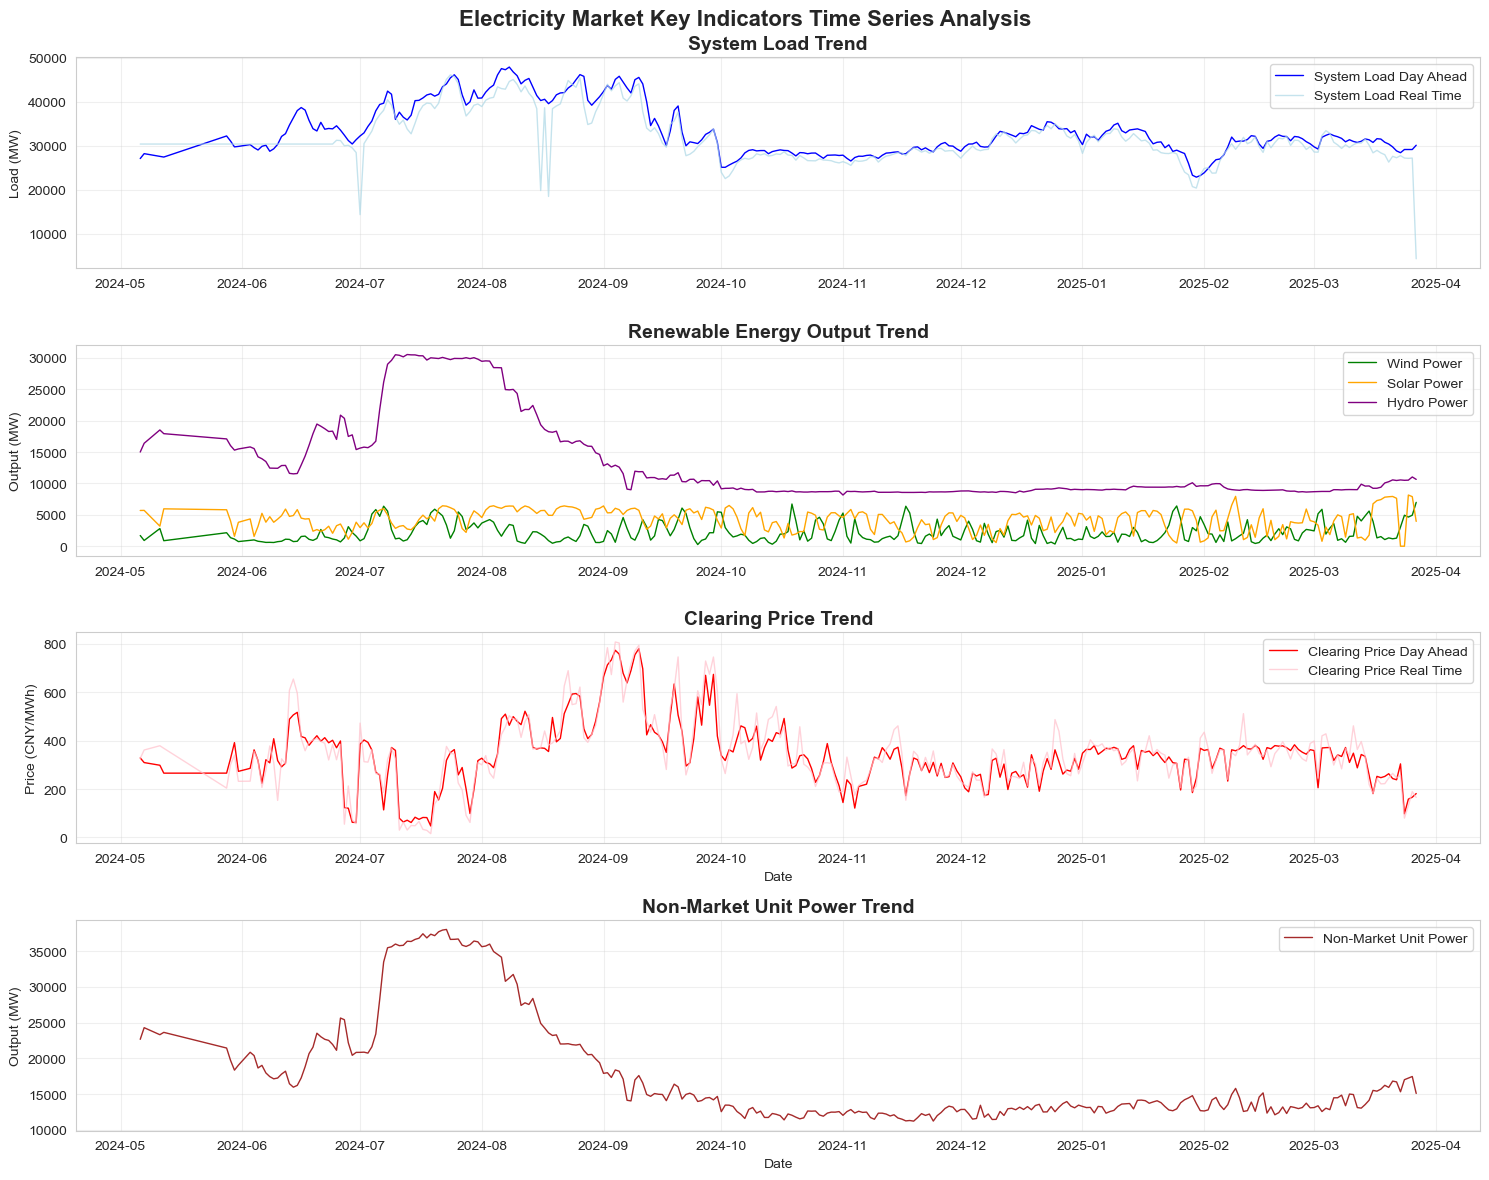

In [6]:
fig, axes = plt.subplots(4, 1, figsize=(15, 12))

# 系统负荷趋势
axes[0].plot(daily_data['date'], daily_data['system_load_day_ahead'], 
             label='System Load Day Ahead', color='blue', linewidth=1)
axes[0].plot(daily_data['date'], daily_data['system_load_real_time'], 
             label='System Load Real Time', color='lightblue', linewidth=1, alpha=0.7)
axes[0].set_title('System Load Trend', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Load (MW)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 新能源出力趋势
axes[1].plot(daily_data['date'], daily_data['wind_power_day_ahead'], 
             label='Wind Power', color='green', linewidth=1)
axes[1].plot(daily_data['date'], daily_data['solar_power_day_ahead'], 
             label='Solar Power', color='orange', linewidth=1)
axes[1].plot(daily_data['date'], daily_data['hydro_power_day_ahead'], 
             label='Hydro Power', color='purple', linewidth=1)
axes[1].set_title('Renewable Energy Output Trend', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Output (MW)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# 出清价格趋势
axes[2].plot(daily_data['date'], daily_data['clearing_price_day_ahead'], 
             label='Clearing Price Day Ahead', color='red', linewidth=1)
axes[2].plot(daily_data['date'], daily_data['clearing_price_real_time'], 
             label='Clearing Price Real Time', color='pink', linewidth=1, alpha=0.7)
axes[2].set_title('Clearing Price Trend', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Date')
axes[2].set_ylabel('Price (CNY/MWh)')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

# 非市场化机组处理趋势
axes[3].plot(daily_data['date'], daily_data['non_market_unit_power_day_ahead'], 
             label='Non-Market Unit Power', color='brown', linewidth=1)
axes[3].set_title('Non-Market Unit Power Trend', fontsize=14, fontweight='bold')
axes[3].set_xlabel('Date')
axes[3].set_ylabel('Output (MW)')
axes[3].legend()
axes[3].grid(True, alpha=0.3)

plt.suptitle('Electricity Market Key Indicators Time Series Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. 电价特征分析

### 4.1 电价波动分析

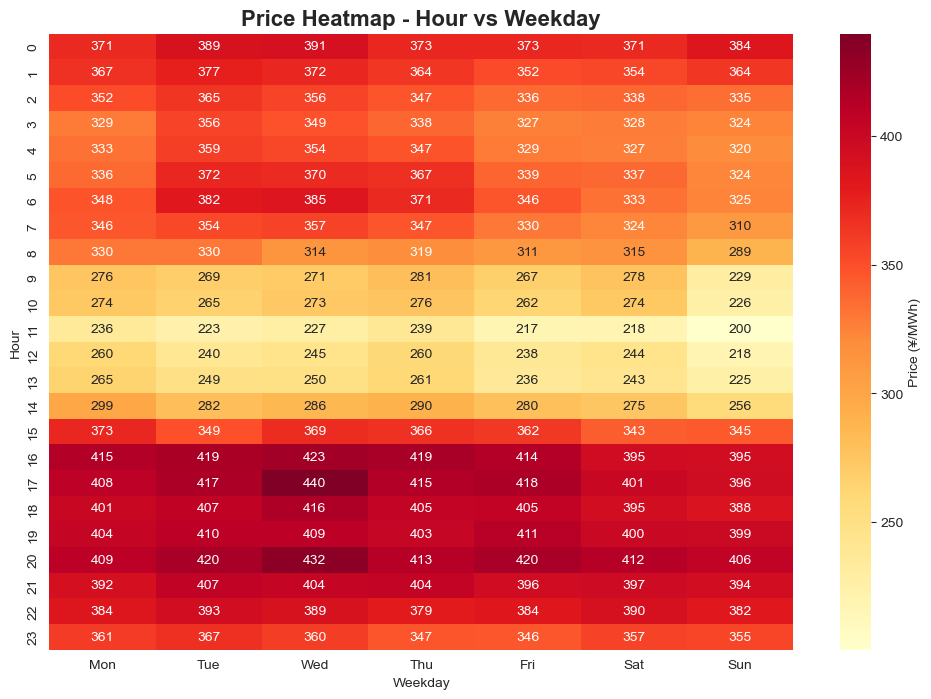

In [7]:
# 创建小时-星期电价热力图
heatmap_data = df_en.pivot_table(values='clearing_price_day_ahead', 
                                index='hour', columns='weekday', aggfunc='mean')

plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, cmap='YlOrRd', annot=True, fmt='.0f', 
            cbar_kws={'label': 'Price (¥/MWh)'})
plt.title('Price Heatmap - Hour vs Weekday', fontsize=16, fontweight='bold')
plt.xlabel('Weekday')
plt.ylabel('Hour')
plt.xticks(ticks=[0.5,1.5,2.5,3.5,4.5,5.5,6.5], 
            labels=['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
plt.show()

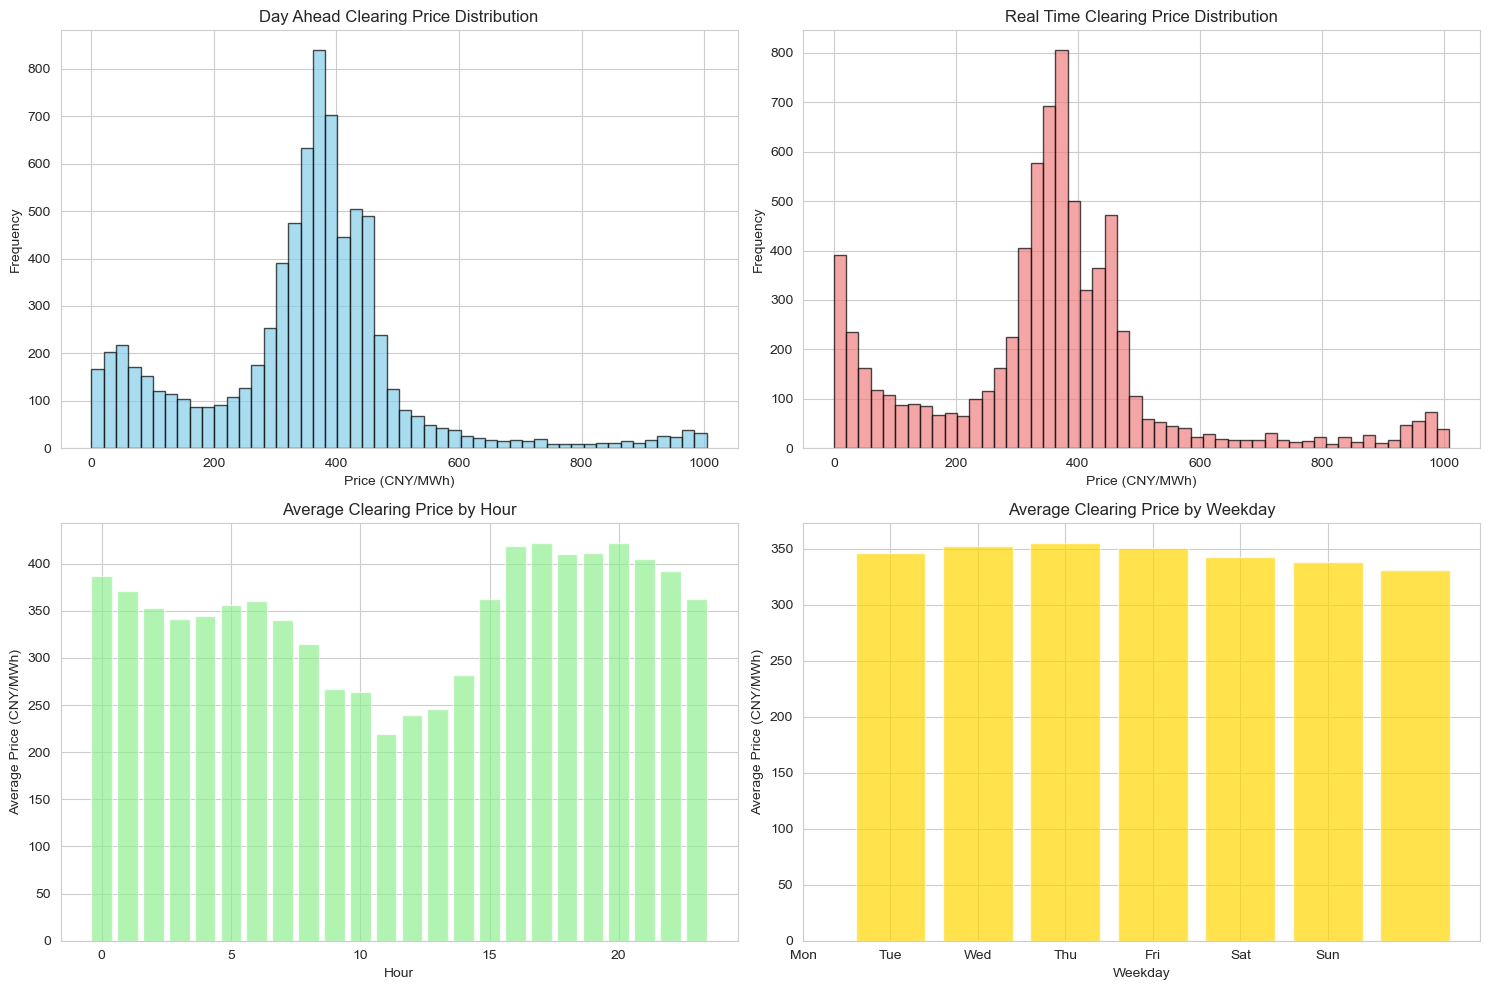

In [14]:
# 价格分布分析
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 日前价格分布
axes[0,0].hist(df_en['clearing_price_day_ahead'].dropna(), bins=50, alpha=0.7, color='skyblue', edgecolor='black')
axes[0,0].set_title('Day Ahead Clearing Price Distribution')
axes[0,0].set_xlabel('Price (CNY/MWh)')
axes[0,0].set_ylabel('Frequency')

# 实时价格分布
axes[0,1].hist(df_en['clearing_price_real_time'].dropna(), bins=50, alpha=0.7, color='lightcoral', edgecolor='black')
axes[0,1].set_title('Real Time Clearing Price Distribution')
axes[0,1].set_xlabel('Price (CNY/MWh)')
axes[0,1].set_ylabel('Frequency')

# 价格箱线图（按小时）
hourly_price = df_en.groupby('hour')['clearing_price_day_ahead'].mean()
axes[1,0].bar(hourly_price.index, hourly_price.values, color='lightgreen', alpha=0.7)
axes[1,0].set_title('Average Clearing Price by Hour')
axes[1,0].set_xlabel('Hour')
axes[1,0].set_ylabel('Average Price (CNY/MWh)')

# 价格箱线图（按星期）
weekday_price = df_en.groupby('weekday')['clearing_price_day_ahead'].mean()
weekday_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
axes[1,1].bar(weekday_price.index, weekday_price.values, color='gold', alpha=0.7)
axes[1,1].set_title('Average Clearing Price by Weekday')
axes[1,1].set_xlabel('Weekday')
axes[1,1].set_xticks(range(7))
axes[1,1].set_xticklabels(weekday_labels)
axes[1,1].set_ylabel('Average Price (CNY/MWh)')

plt.tight_layout()
plt.show()

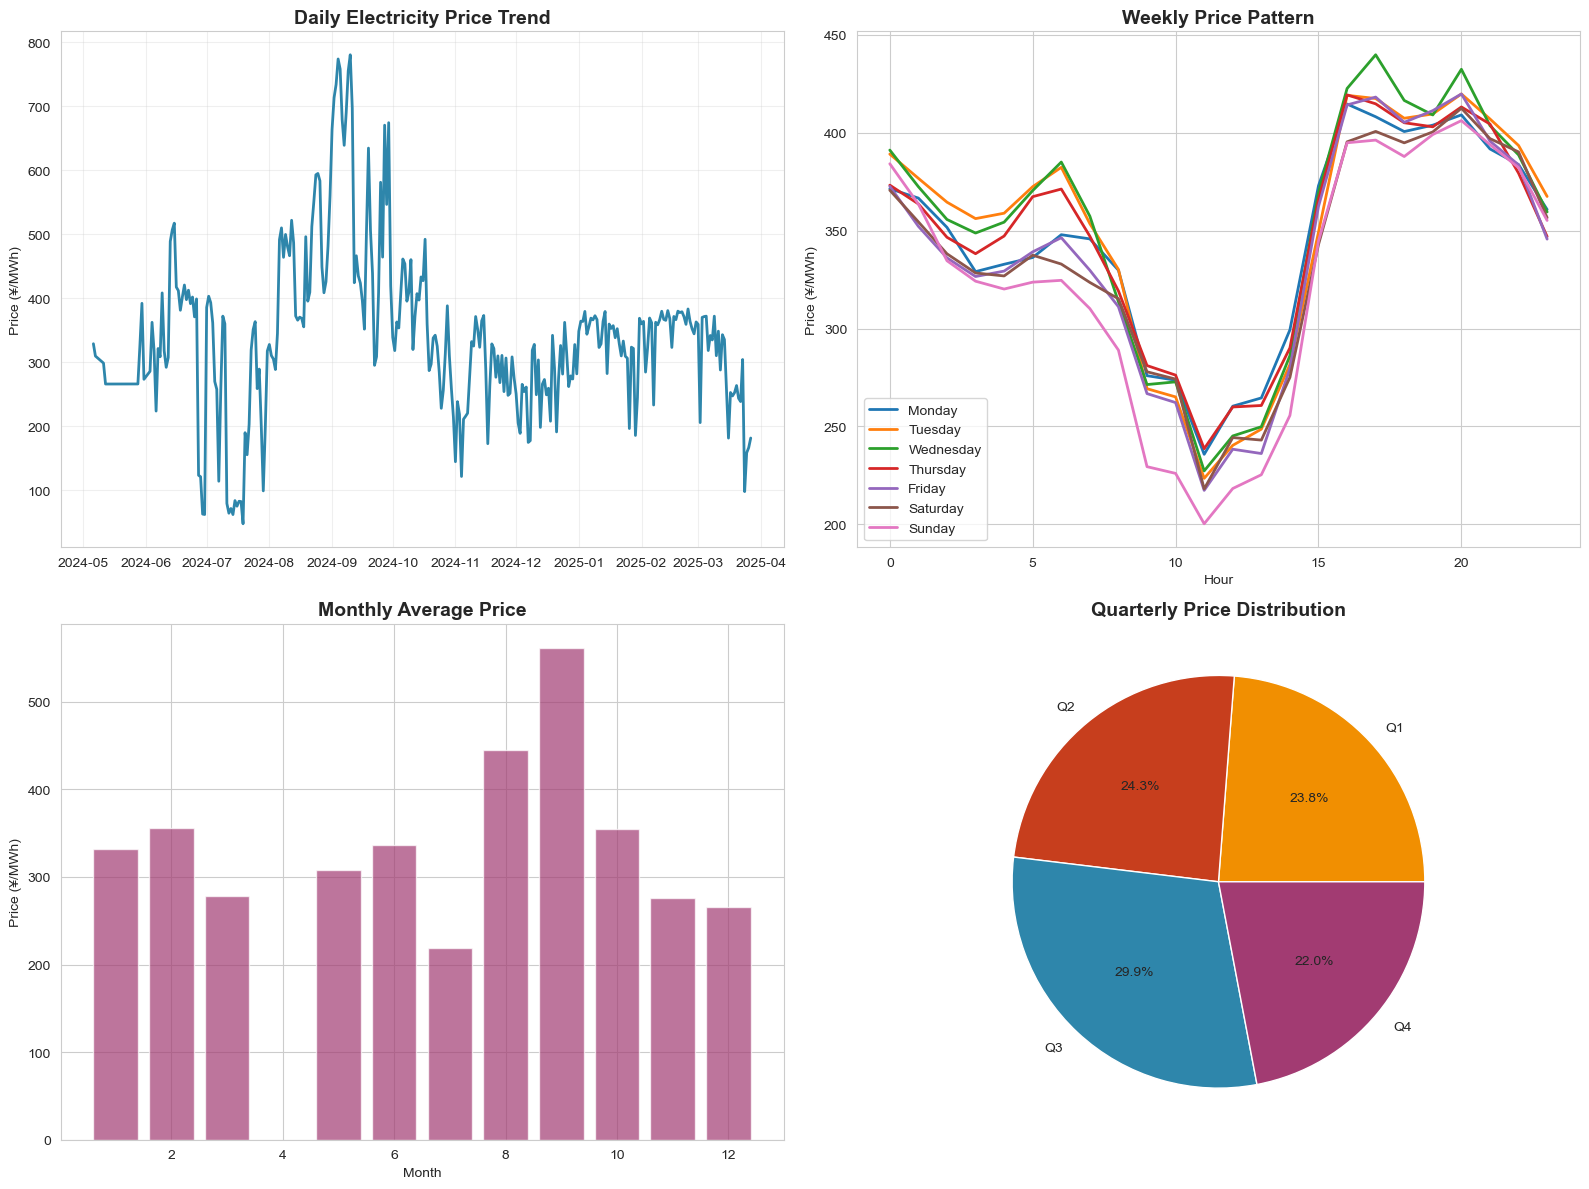

In [8]:
# 多时间尺度电价分析
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 日度趋势
daily_price = df_en.groupby('date')['clearing_price_day_ahead'].mean()
axes[0,0].plot(daily_price.index, daily_price.values, linewidth=2, color='#2E86AB')
axes[0,0].set_title('Daily Electricity Price Trend', fontsize=14, fontweight='bold')
axes[0,0].set_ylabel('Price (¥/MWh)')
axes[0,0].grid(True, alpha=0.3)
    
# 周度模式
weekly_pattern = df_en.groupby(['weekday', 'hour'])['clearing_price_day_ahead'].mean().unstack(0)
weekly_pattern.plot(ax=axes[0,1], linewidth=2)
axes[0,1].set_title('Weekly Price Pattern', fontsize=14, fontweight='bold')
axes[0,1].set_xlabel('Hour')
axes[0,1].set_ylabel('Price (¥/MWh)')
axes[0,1].legend(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])

# 月度趋势
monthly_price = df_en.groupby('month')['clearing_price_day_ahead'].mean()
axes[1,0].bar(monthly_price.index, monthly_price.values, color='#A23B72', alpha=0.7)
axes[1,0].set_title('Monthly Average Price', fontsize=14, fontweight='bold')
axes[1,0].set_xlabel('Month')
axes[1,0].set_ylabel('Price (¥/MWh)')

# 季度对比
seasonal_price = df_en.groupby('quarter')['clearing_price_day_ahead'].mean()
axes[1,1].pie(seasonal_price.values, labels=['Q1', 'Q2', 'Q3', 'Q4'], 
                autopct='%1.1f%%', colors=['#F18F01', '#C73E1D', '#2E86AB', '#A23B72'])
axes[1,1].set_title('Quarterly Price Distribution', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

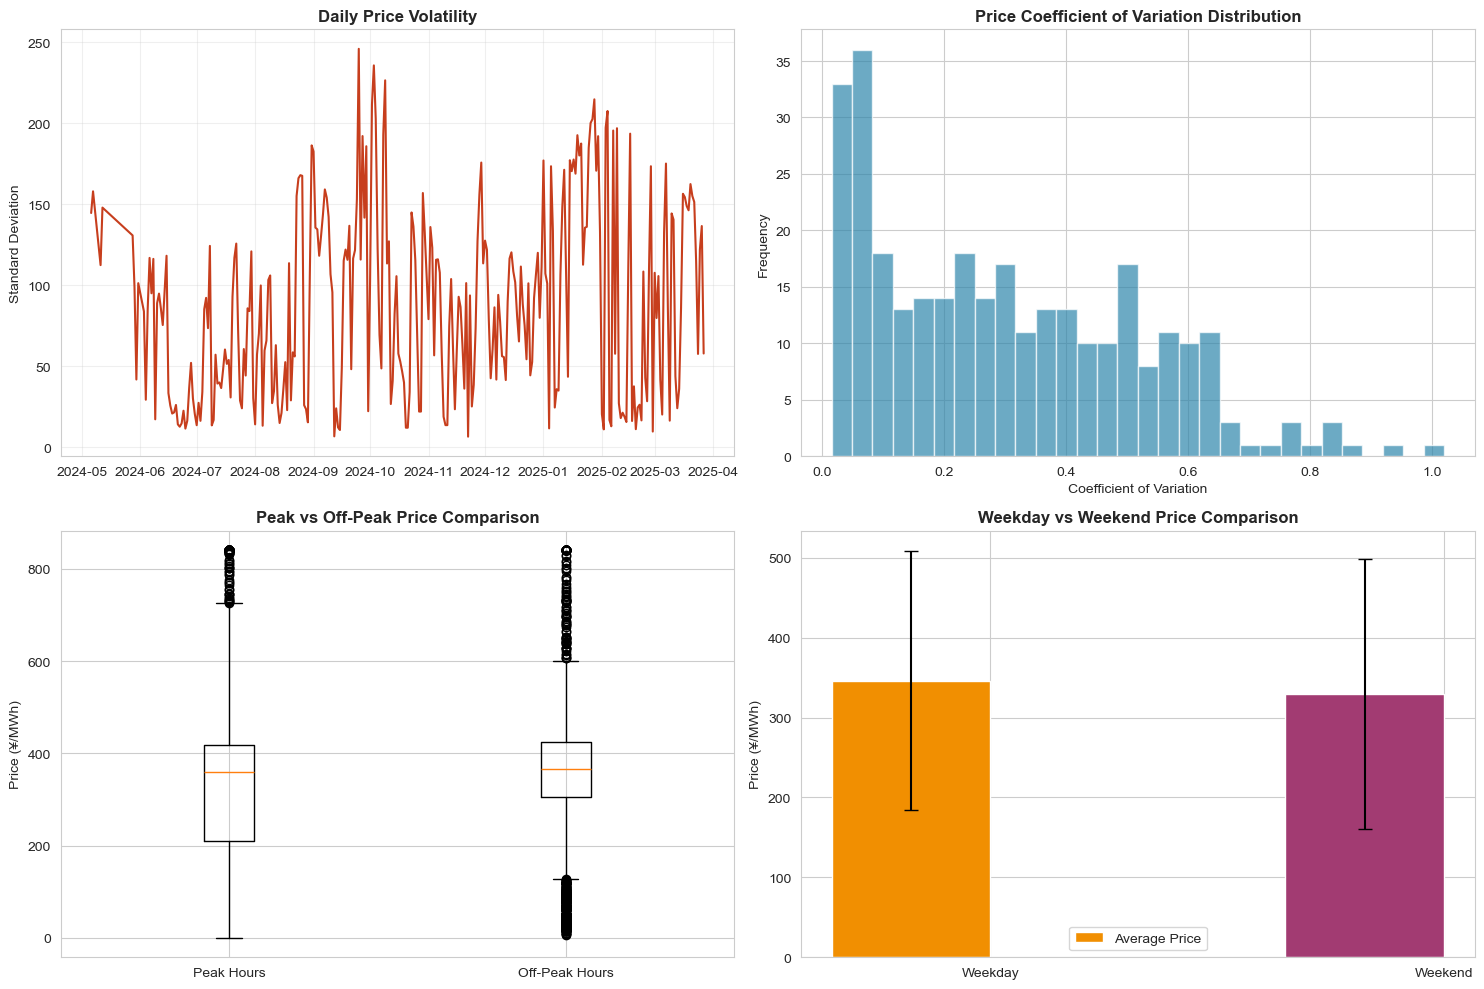

In [9]:
# 计算日度价格波动率
daily_volatility = df_en.groupby('date')['clearing_price_day_ahead'].agg(['mean', 'std'])
daily_volatility['cv'] = daily_volatility['std'] / daily_volatility['mean']  # 变异系数

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 波动率时间序列
axes[0,0].plot(daily_volatility.index, daily_volatility['std'], color='#C73E1D')
axes[0,0].set_title('Daily Price Volatility', fontweight='bold')
axes[0,0].set_ylabel('Standard Deviation')
axes[0,0].grid(True, alpha=0.3)

# 变异系数分布
axes[0,1].hist(daily_volatility['cv'].dropna(), bins=30, color='#2E86AB', alpha=0.7)
axes[0,1].set_title('Price Coefficient of Variation Distribution', fontweight='bold')
axes[0,1].set_xlabel('Coefficient of Variation')
axes[0,1].set_ylabel('Frequency')

# 高峰vs非高峰价格对比
peak_hours = df_en[df_en['is_peak_hour'] == 1]['clearing_price_day_ahead']
off_peak_hours = df_en[df_en['is_peak_hour'] == 0]['clearing_price_day_ahead']

box_data = [peak_hours.dropna(), off_peak_hours.dropna()]
axes[1,0].boxplot(box_data, labels=['Peak Hours', 'Off-Peak Hours'])
axes[1,0].set_title('Peak vs Off-Peak Price Comparison', fontweight='bold')
axes[1,0].set_ylabel('Price (¥/MWh)')

# 周末vs工作日价格对比
weekend_prices = df_en[df_en['is_weekend'] == 1]['clearing_price_day_ahead']
weekday_prices = df_en[df_en['is_weekend'] == 0]['clearing_price_day_ahead']

weekend_stats = [weekend_prices.mean(), weekend_prices.std()]
weekday_stats = [weekday_prices.mean(), weekday_prices.std()]

x = np.arange(2)
width = 0.35
axes[1,1].bar(x - width/2, [weekday_stats[0], weekend_stats[0]], 
                width, label='Average Price', yerr=[weekday_stats[1], weekend_stats[1]],
                capsize=5, color=['#F18F01', '#A23B72'])
axes[1,1].set_title('Weekday vs Weekend Price Comparison', fontweight='bold')
axes[1,1].set_xticks(x)
axes[1,1].set_xticklabels(['Weekday', 'Weekend'])
axes[1,1].set_ylabel('Price (¥/MWh)')
axes[1,1].legend()

plt.tight_layout()
plt.show()

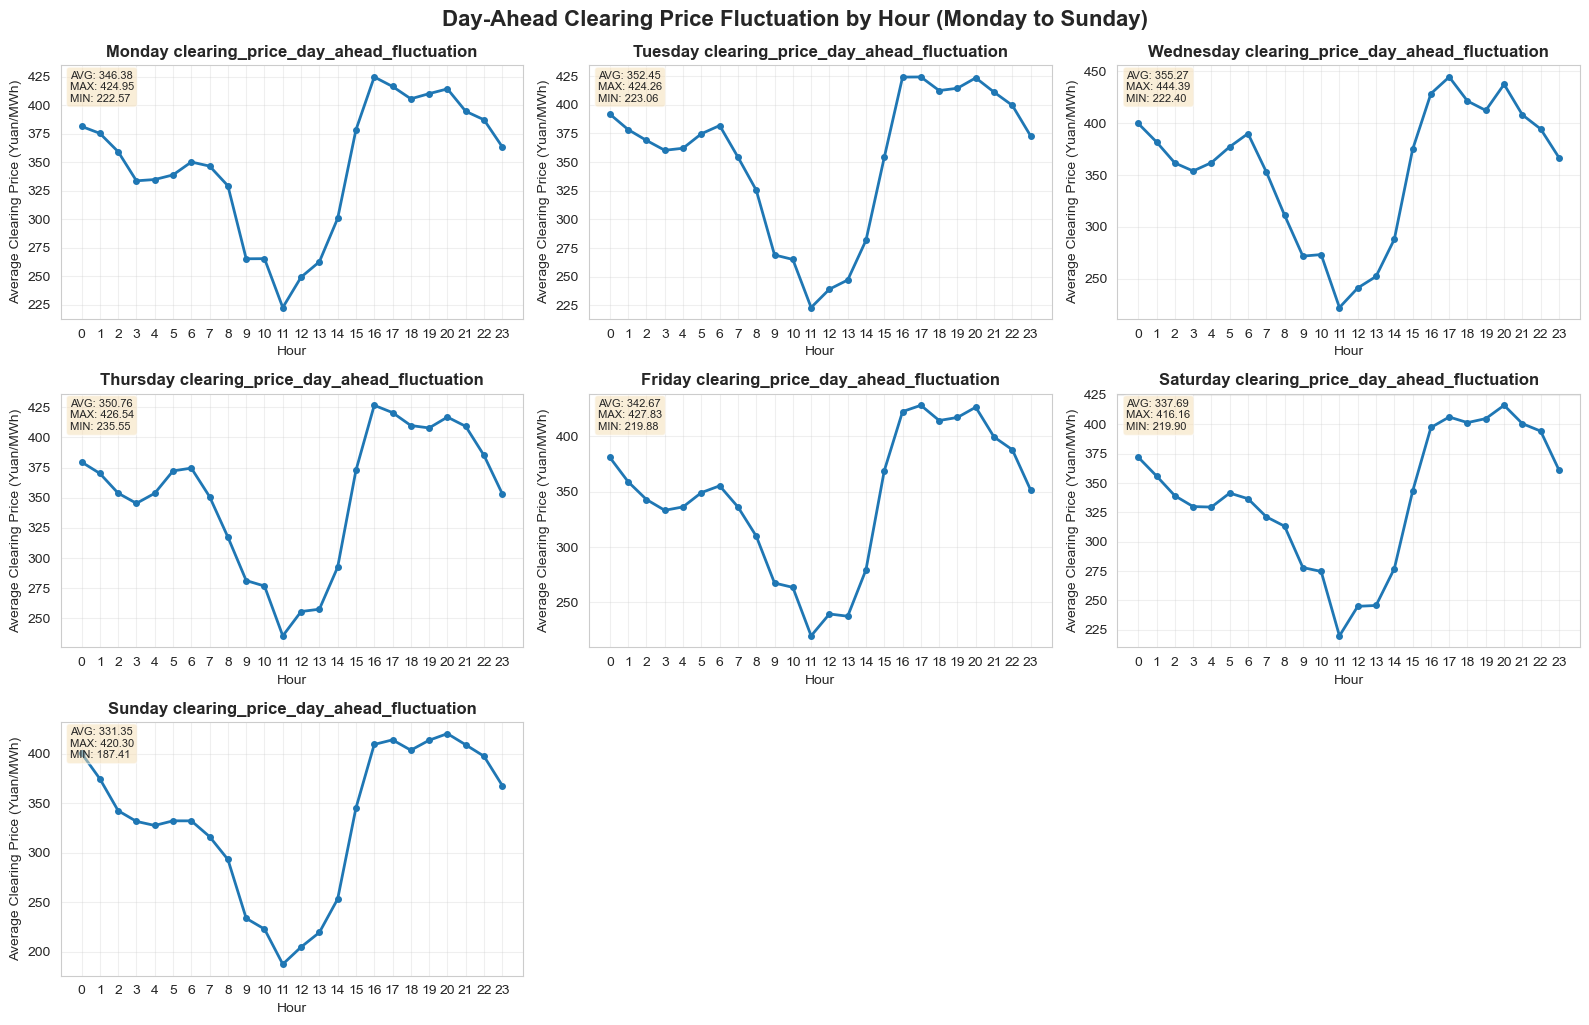

In [17]:
# 创建周一到周日每小时的电价波动图
plt.figure(figsize=(16, 10))

# 定义星期名称
weekday_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# 为每个星期创建一个子图
for weekday in range(1, 8):
    plt.subplot(3, 3, weekday)
    
    # 筛选该星期的数据
    weekday_data = df_en[df_en['weekday'] == weekday]
    
    # 按小时计算平均电价
    hourly_prices = weekday_data.groupby('hour')['clearing_price_day_ahead'].mean()
    
    # 绘制折线图
    plt.plot(hourly_prices.index, hourly_prices.values, marker='o', linewidth=2, markersize=4)
    plt.title(f'{weekday_names[weekday-1]} clearing_price_day_ahead_fluctuation', fontsize=12, fontweight='bold')
    plt.xlabel('Hour', fontsize=10)  
    plt.ylabel('Average Clearing Price (Yuan/MWh)', fontsize=10)  
    plt.grid(True, alpha=0.3)
    plt.xticks(range(0, 24))
    
    # 添加一些统计信息
    avg_price = hourly_prices.mean()
    max_price = hourly_prices.max()
    min_price = hourly_prices.min()
    plt.text(0.02, 0.98, f'AVG: {avg_price:.2f}\nMAX: {max_price:.2f}\nMIN: {min_price:.2f}', 
             transform=plt.gca().transAxes, fontsize=8, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.suptitle('Day-Ahead Clearing Price Fluctuation by Hour (Monday to Sunday)', fontsize=16, fontweight='bold', y=1.02)
plt.show()


各星期日前出清电价统计信息：
  Weekday Avg Price Max Price Min Price Price Std Dev
   Monday    346.38    424.95    222.57         58.45
  Tuesday    352.45    424.26    223.06         63.89
Wednesday    355.27    444.39    222.40         65.34
 Thursday    350.76    426.54    235.55         57.03
   Friday    342.67    427.83    219.88         63.56
 Saturday    337.69    416.16    219.90         57.22
   Sunday    331.35    420.30    187.41         75.15


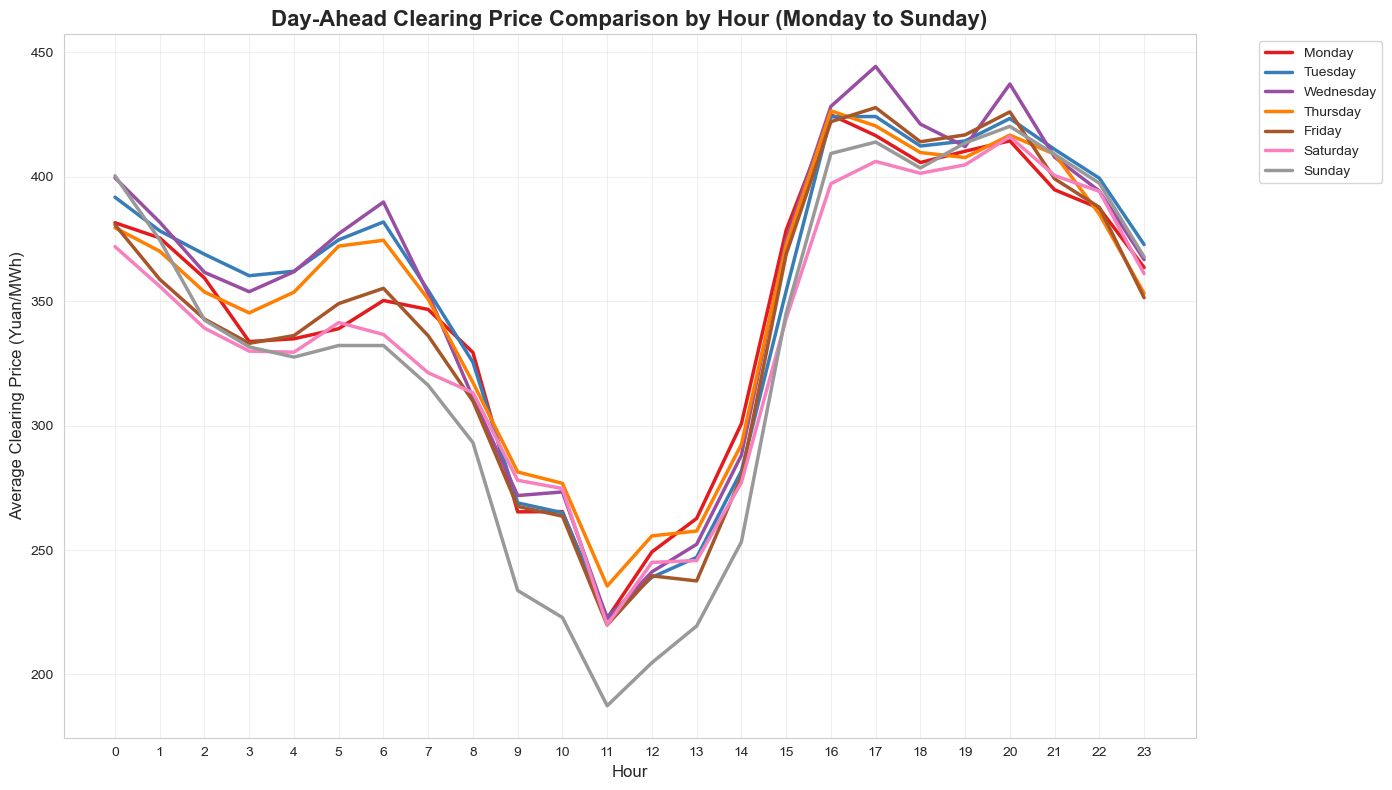

In [18]:
# 创建所有星期叠加对比图
plt.figure(figsize=(14, 8))

# 为每个星期绘制曲线
colors = plt.cm.Set1(np.linspace(0, 1, 7))
for weekday in range(1, 8):
    weekday_data = df_en[df_en['weekday'] == weekday]
    hourly_prices = weekday_data.groupby('hour')['clearing_price_day_ahead'].mean()
    
    plt.plot(hourly_prices.index, hourly_prices.values, 
             label=weekday_names[weekday-1], linewidth=2.5, color=colors[weekday-1])

plt.title('Day-Ahead Clearing Price Comparison by Hour (Monday to Sunday)', fontsize=16, fontweight='bold')
plt.xlabel('Hour', fontsize=12)  
plt.ylabel('Average Clearing Price (Yuan/MWh)', fontsize=12)  
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.xticks(range(0, 24))

# 添加统计表格
weekday_stats = []
for weekday in range(1, 8):
    weekday_data = df_en[df_en['weekday'] == weekday]
    hourly_prices = weekday_data.groupby('hour')['clearing_price_day_ahead'].mean()
    
    stats = {
        'Weekday': weekday_names[weekday-1], 
        'Avg Price': f'{hourly_prices.mean():.2f}',  
        'Max Price': f'{hourly_prices.max():.2f}',  
        'Min Price': f'{hourly_prices.min():.2f}', 
        'Price Std Dev': f'{hourly_prices.std():.2f}'  
    }
    weekday_stats.append(stats)

stats_df = pd.DataFrame(weekday_stats)
print("\n各星期日前出清电价统计信息：")
print(stats_df.to_string(index=False))

plt.tight_layout()
plt.show()

### 4.2 电价滞后项分析

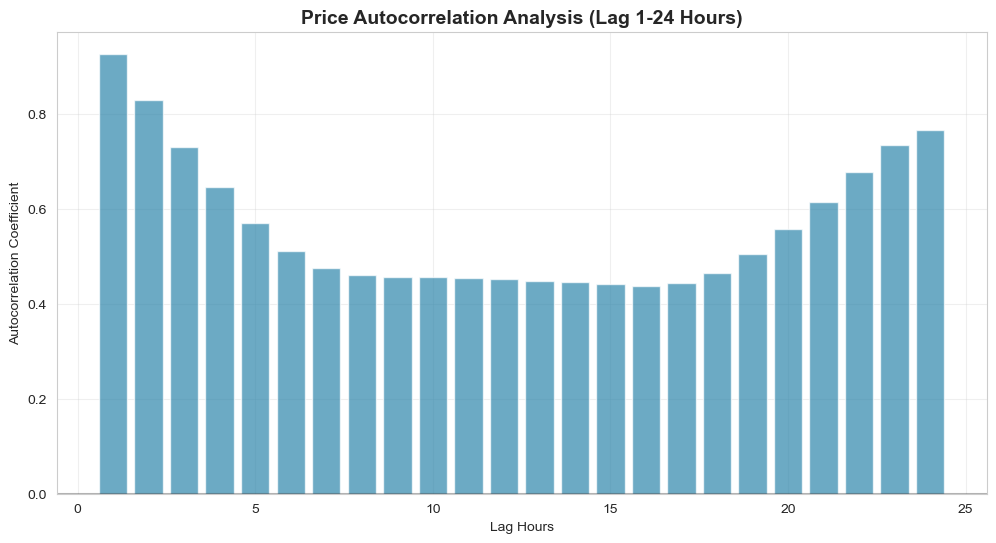


Significant autocorrelation lag features (|correlation| > 0.5):
Lag 1 hours: 0.926
Lag 2 hours: 0.830
Lag 3 hours: 0.730
Lag 4 hours: 0.645
Lag 5 hours: 0.570
Lag 6 hours: 0.511
Lag 19 hours: 0.505
Lag 20 hours: 0.556
Lag 21 hours: 0.615
Lag 22 hours: 0.678
Lag 23 hours: 0.734
Lag 24 hours: 0.765


In [10]:
# 创建滞后特征
price_data = df_en['clearing_price_day_ahead'].dropna()

# 计算不同滞后期的自相关性
lags = range(1, 25)  # 1-24小时滞后
autocorrelations = [price_data.autocorr(lag=lag) for lag in lags]

plt.figure(figsize=(12, 6))
plt.bar(lags, autocorrelations, color='#2E86AB', alpha=0.7)
plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)
plt.title('Price Autocorrelation Analysis (Lag 1-24 Hours)', fontsize=14, fontweight='bold')
plt.xlabel('Lag Hours')
plt.ylabel('Autocorrelation Coefficient')
plt.grid(True, alpha=0.3)
plt.show()

# 显示最重要的滞后特征
significant_lags = [(lag, corr) for lag, corr in zip(lags, autocorrelations) if abs(corr) > 0.5]
print("\nSignificant autocorrelation lag features (|correlation| > 0.5):")
for lag, corr in significant_lags:
    print(f"Lag {lag} hours: {corr:.3f}")

### 4.3 电价季节性分析

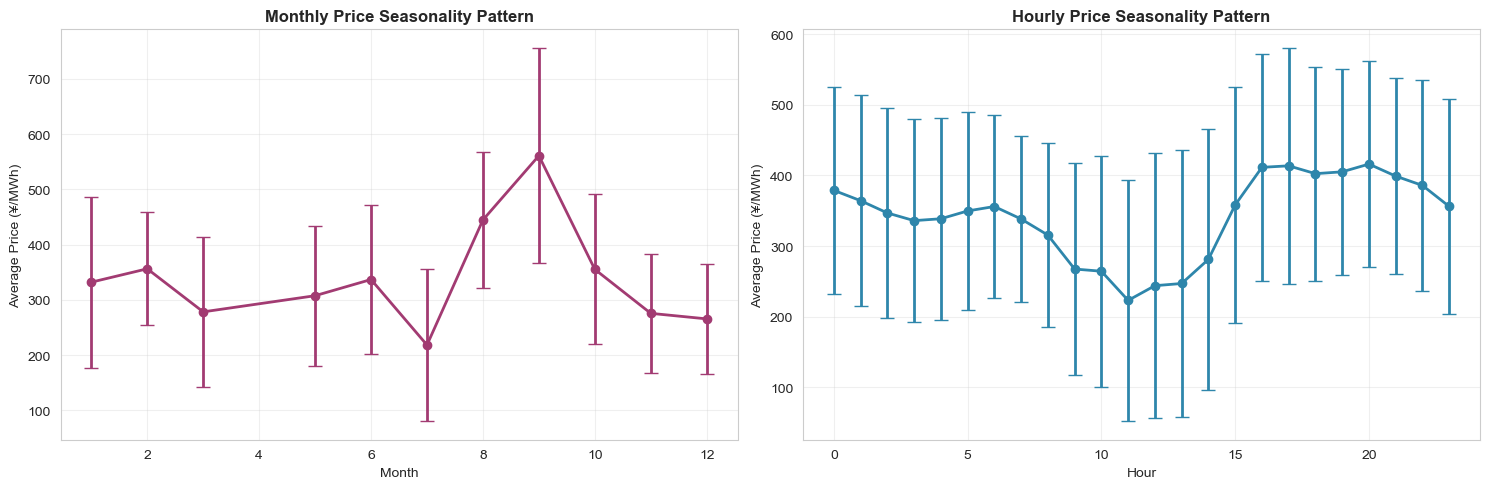

In [11]:
# 月度季节性分析
monthly_seasonality = df_en.groupby('month')['clearing_price_day_ahead'].agg(['mean', 'std'])

# 小时季节性分析
hourly_seasonality = df_en.groupby('hour')['clearing_price_day_ahead'].agg(['mean', 'std'])

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 月度季节性
axes[0].errorbar(monthly_seasonality.index, monthly_seasonality['mean'], 
                    yerr=monthly_seasonality['std'], fmt='o-', color='#A23B72', 
                    capsize=5, linewidth=2)
axes[0].set_title('Monthly Price Seasonality Pattern', fontweight='bold')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Average Price (¥/MWh)')
axes[0].grid(True, alpha=0.3)

# 小时季节性
axes[1].errorbar(hourly_seasonality.index, hourly_seasonality['mean'], 
                    yerr=hourly_seasonality['std'], fmt='o-', color='#2E86AB', 
                    capsize=5, linewidth=2)
axes[1].set_title('Hourly Price Seasonality Pattern', fontweight='bold')
axes[1].set_xlabel('Hour')
axes[1].set_ylabel('Average Price (¥/MWh)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 4.4 电价与负荷的关系分析

<Figure size 1200x800 with 0 Axes>

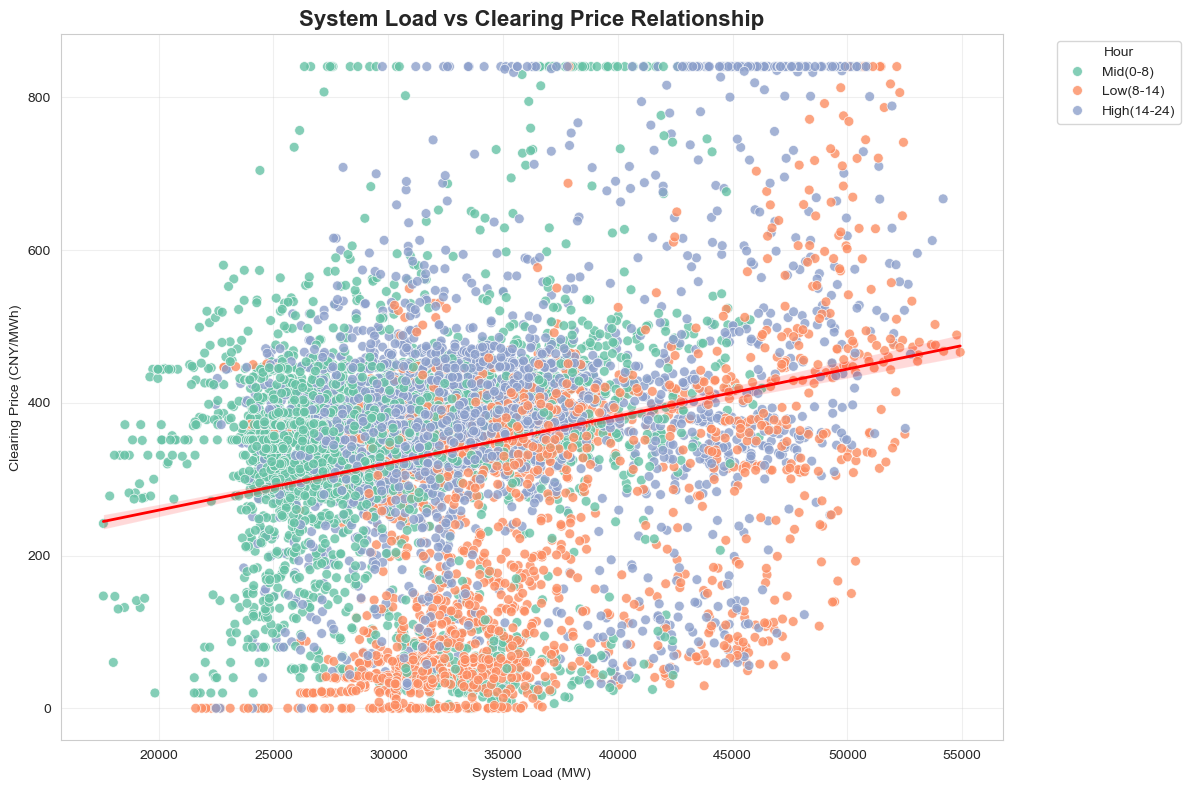

=== Key Variables Correlation Matrix ===


,system_load_day_ahead,system_load_real_time,clearing_price_day_ahead,clearing_price_real_time
system_load_day_ahead,1.000,0.865,0.251,0.207
system_load_real_time,0.865,1.000,0.344,0.316
clearing_price_day_ahead,0.251,0.344,1.000,0.874
clearing_price_real_time,0.207,0.316,0.874,1.000


In [12]:
# 价格与负荷的关系分析
plt.figure(figsize=(12, 8))

# 将散点依据低、中、高峰进行划分
df_en['time_period'] = pd.cut(df_en['hour'], 
                               bins=[0, 8, 14, 24],  # 自定义区间
                               labels=['Mid(0-8)', 'Low(8-14)', 'High(14-24)'],
                               include_lowest=True)

plt.figure(figsize=(12, 8))
scatter_plot = sns.scatterplot(data=df_en, x='system_load_day_ahead', y='clearing_price_day_ahead', 
                               hue='time_period', palette='Set2', alpha=0.8, s=50)

# 添加趋势线
sns.regplot(data=df_en, x='system_load_day_ahead', y='clearing_price_day_ahead', 
            scatter=False, color='red', line_kws={'linewidth': 2})

plt.title('System Load vs Clearing Price Relationship', fontsize=16, fontweight='bold')
plt.xlabel('System Load (MW)')
plt.ylabel('Clearing Price (CNY/MWh)')
plt.legend(title='Hour', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 计算相关系数
correlation = df_en[['system_load_day_ahead', 'system_load_real_time', 
                    'clearing_price_day_ahead', 'clearing_price_real_time']].corr()
print("=== Key Variables Correlation Matrix ===")
display(correlation.round(3))

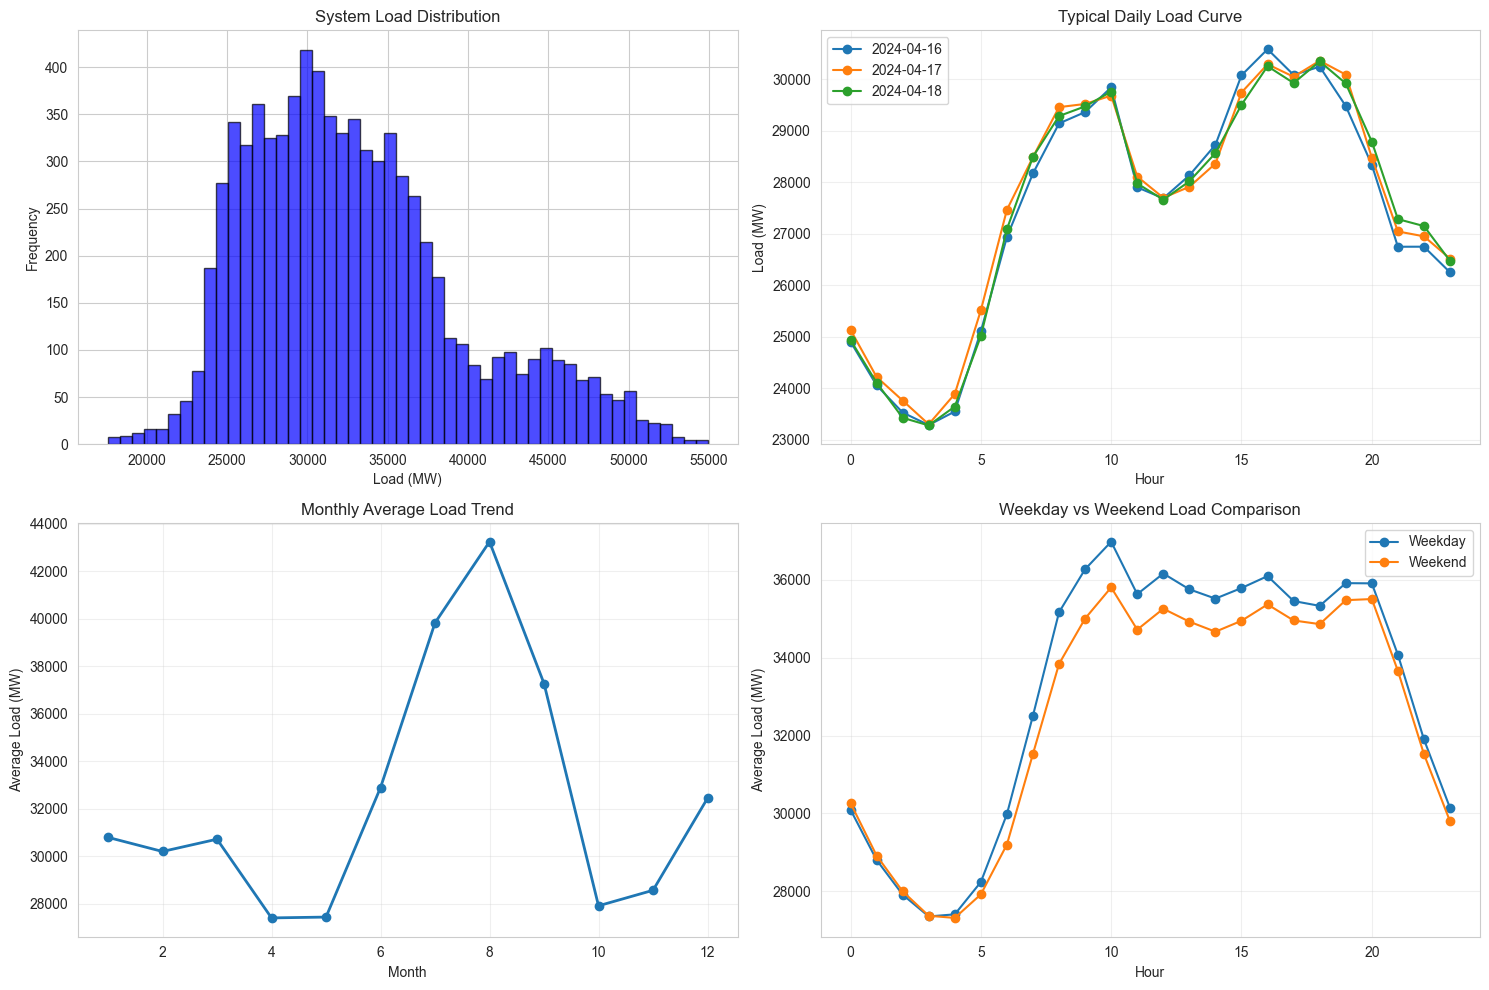

In [30]:
# 负荷模式分析
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 负荷分布
axes[0,0].hist(df_en['system_load_day_ahead'].dropna(), bins=50, alpha=0.7, color='blue', edgecolor='black')
axes[0,0].set_title('System Load Distribution')
axes[0,0].set_xlabel('Load (MW)')
axes[0,0].set_ylabel('Frequency')

# 典型日负荷曲线（取一周数据为例）
week_data = df_en[df_en['date'] <= df_en['date'].min() + pd.Timedelta(days=7)]
hourly_load = week_data.groupby(['date', 'hour'])['system_load_day_ahead'].mean().reset_index()

for date in hourly_load['date'].unique()[:3]:  # 显示前3天的曲线
    day_data = hourly_load[hourly_load['date'] == date]
    axes[0,1].plot(day_data['hour'], day_data['system_load_day_ahead'], 
                   label=date.strftime('%Y-%m-%d'), marker='o')

axes[0,1].set_title('Typical Daily Load Curve')
axes[0,1].set_xlabel('Hour')
axes[0,1].set_ylabel('Load (MW)')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# 负荷季节性分析（按月）
monthly_load = df_en.groupby('month')['system_load_day_ahead'].mean()
axes[1,0].plot(monthly_load.index, monthly_load.values, marker='o', linewidth=2)
axes[1,0].set_title('Monthly Average Load Trend')
axes[1,0].set_xlabel('Month')
axes[1,0].set_ylabel('Average Load (MW)')
axes[1,0].grid(True, alpha=0.3)

# 工作日 vs 周末负荷对比
weekend_load = df_en.groupby(['is_weekend', 'hour'])['system_load_day_ahead'].mean().reset_index()

for weekend in [0, 1]:
    data = weekend_load[weekend_load['is_weekend'] == weekend]
    label = 'Weekday' if weekend == 0 else 'Weekend'
    axes[1,1].plot(data['hour'], data['system_load_day_ahead'], label=label, marker='o')

axes[1,1].set_title('Weekday vs Weekend Load Comparison')
axes[1,1].set_xlabel('Hour')
axes[1,1].set_ylabel('Average Load (MW)')
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. 新能源出力分析

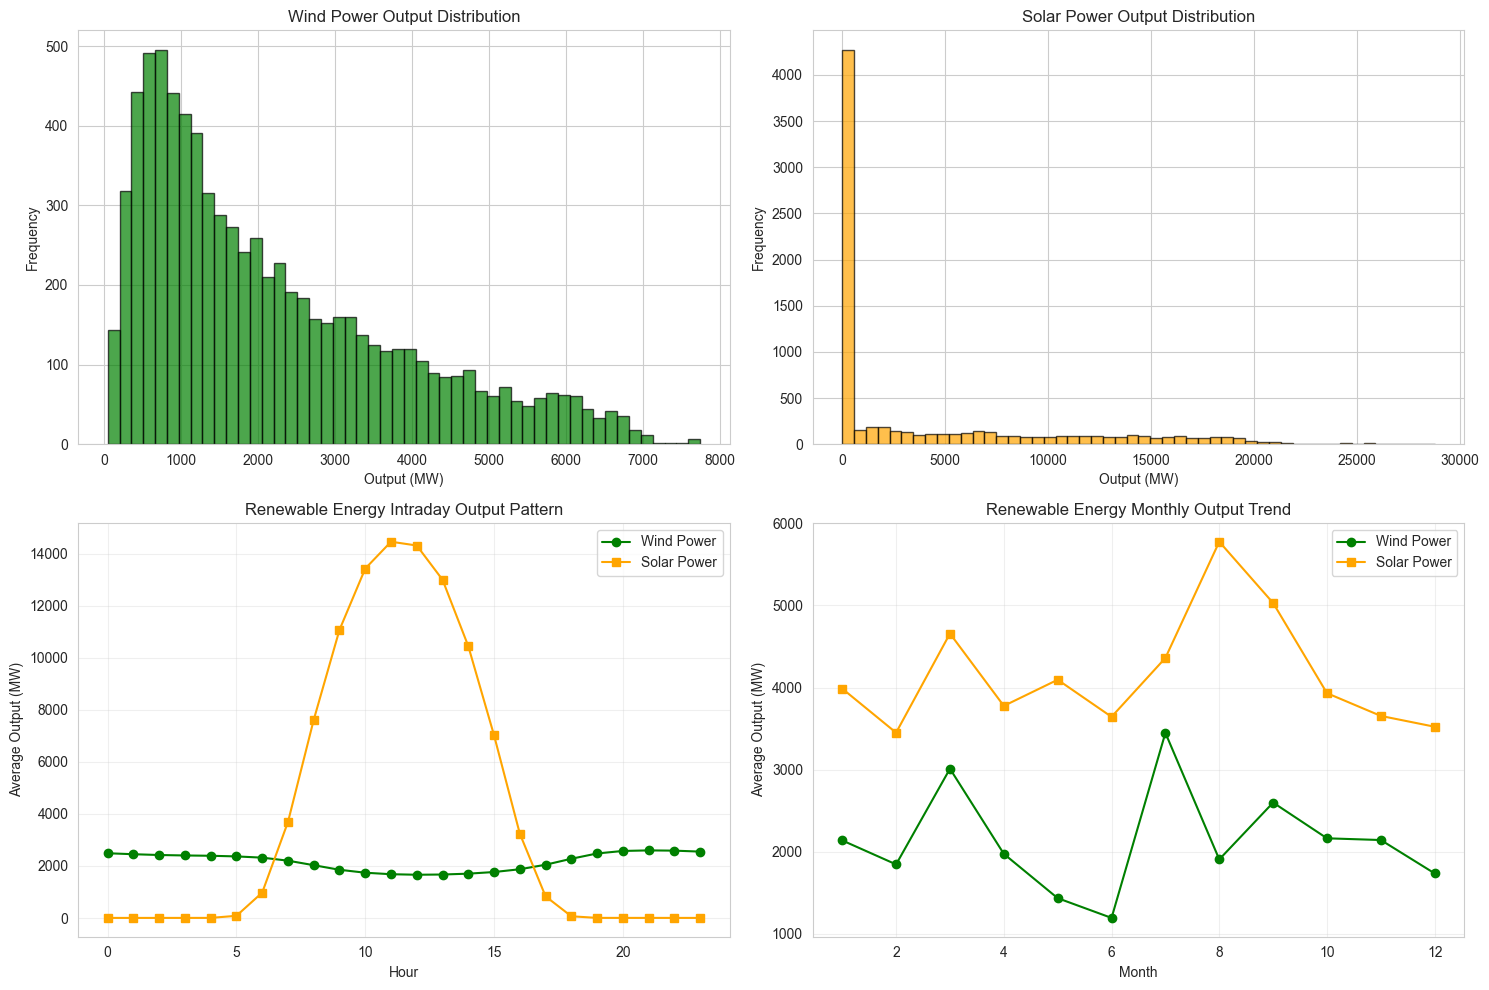

In [31]:
# 新能源出力特征分析
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 风电出力分布
axes[0,0].hist(df_en['wind_power_day_ahead'].dropna(), bins=50, alpha=0.7, color='green', edgecolor='black')
axes[0,0].set_title('Wind Power Output Distribution')
axes[0,0].set_xlabel('Output (MW)')
axes[0,0].set_ylabel('Frequency')

# 光伏出力分布
axes[0,1].hist(df_en['solar_power_day_ahead'].dropna(), bins=50, alpha=0.7, color='orange', edgecolor='black')
axes[0,1].set_title('Solar Power Output Distribution')
axes[0,1].set_xlabel('Output (MW)')
axes[0,1].set_ylabel('Frequency')

# 新能源日内变化模式
hourly_wind = df_en.groupby('hour')['wind_power_day_ahead'].mean()
hourly_solar = df_en.groupby('hour')['solar_power_day_ahead'].mean()

axes[1,0].plot(hourly_wind.index, hourly_wind.values, label='Wind Power', color='green', marker='o')
axes[1,0].plot(hourly_solar.index, hourly_solar.values, label='Solar Power', color='orange', marker='s')
axes[1,0].set_title('Renewable Energy Intraday Output Pattern')
axes[1,0].set_xlabel('Hour')
axes[1,0].set_ylabel('Average Output (MW)')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# 新能源季节性变化
monthly_wind = df_en.groupby('month')['wind_power_day_ahead'].mean()
monthly_solar = df_en.groupby('month')['solar_power_day_ahead'].mean()

axes[1,1].plot(monthly_wind.index, monthly_wind.values, label='Wind Power', color='green', marker='o')
axes[1,1].plot(monthly_solar.index, monthly_solar.values, label='Solar Power', color='orange', marker='s')
axes[1,1].set_title('Renewable Energy Monthly Output Trend')
axes[1,1].set_xlabel('Month')
axes[1,1].set_ylabel('Average Output (MW)')
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. 非市场化机组出力与水电出力

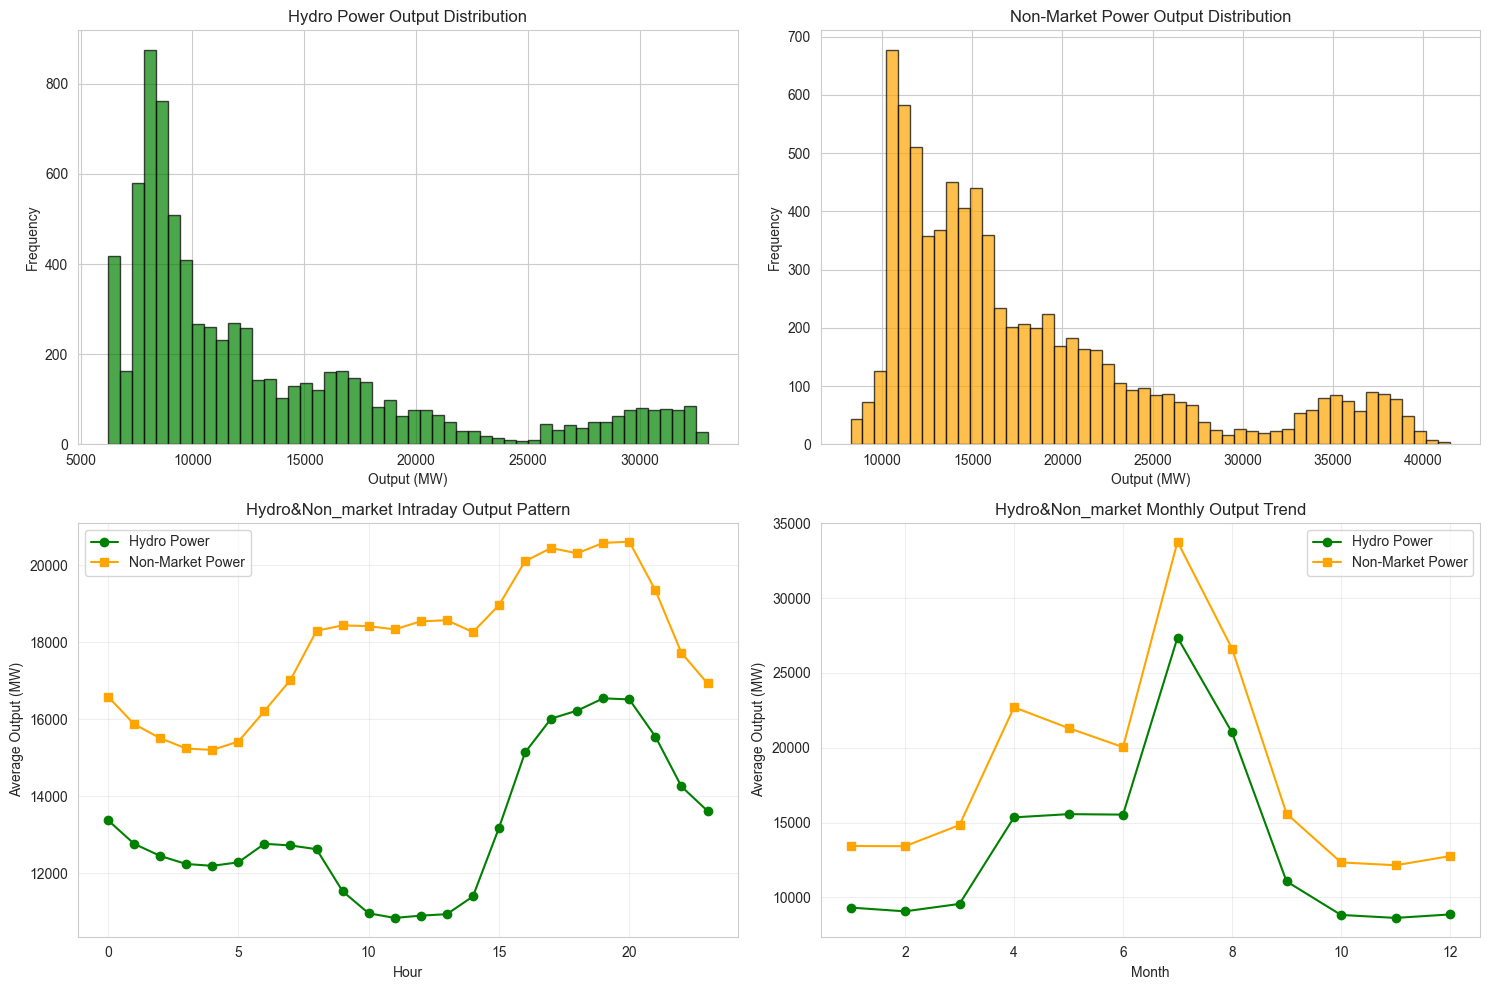

In [39]:
# 新能源出力特征分析
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 水电出力分布
axes[0,0].hist(df_en['hydro_power_day_ahead'].dropna(), bins=50, alpha=0.7, color='green', edgecolor='black')
axes[0,0].set_title('Hydro Power Output Distribution')
axes[0,0].set_xlabel('Output (MW)')
axes[0,0].set_ylabel('Frequency')

# 非市场化机组出力分布
axes[0,1].hist(df_en['non_market_unit_power_day_ahead'].dropna(), bins=50, alpha=0.7, color='orange', edgecolor='black')
axes[0,1].set_title('Non-Market Power Output Distribution') 
axes[0,1].set_xlabel('Output (MW)')
axes[0,1].set_ylabel('Frequency')

# 水电出力与非市场化机组出力日内变化模式
hourly_hydro = df_en.groupby('hour')['hydro_power_day_ahead'].mean()
hourly_non_market = df_en.groupby('hour')['non_market_unit_power_day_ahead'].mean()

axes[1,0].plot(hourly_hydro.index, hourly_hydro.values, label='Hydro Power', color='green', marker='o')
axes[1,0].plot(hourly_non_market.index, hourly_non_market.values, label='Non-Market Power', color='orange', marker='s')
axes[1,0].set_title('Hydro&Non_market Intraday Output Pattern')
axes[1,0].set_xlabel('Hour')
axes[1,0].set_ylabel('Average Output (MW)')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# 水电出力季节性变化
monthly_hydro = df_en.groupby('month')['hydro_power_day_ahead'].mean()
monthly_non_market = df_en.groupby('month')['non_market_unit_power_day_ahead'].mean()

axes[1,1].plot(monthly_hydro.index, monthly_hydro.values, label='Hydro Power', color='green', marker='o')
axes[1,1].plot(monthly_non_market.index, monthly_non_market.values, label='Non-Market Power', color='orange', marker='s')
axes[1,1].set_title('Hydro&Non_market Monthly Output Trend')
axes[1,1].set_xlabel('Month')
axes[1,1].set_ylabel('Average Output (MW)')
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. 多变量关系分析

### 7.1 相关性分析

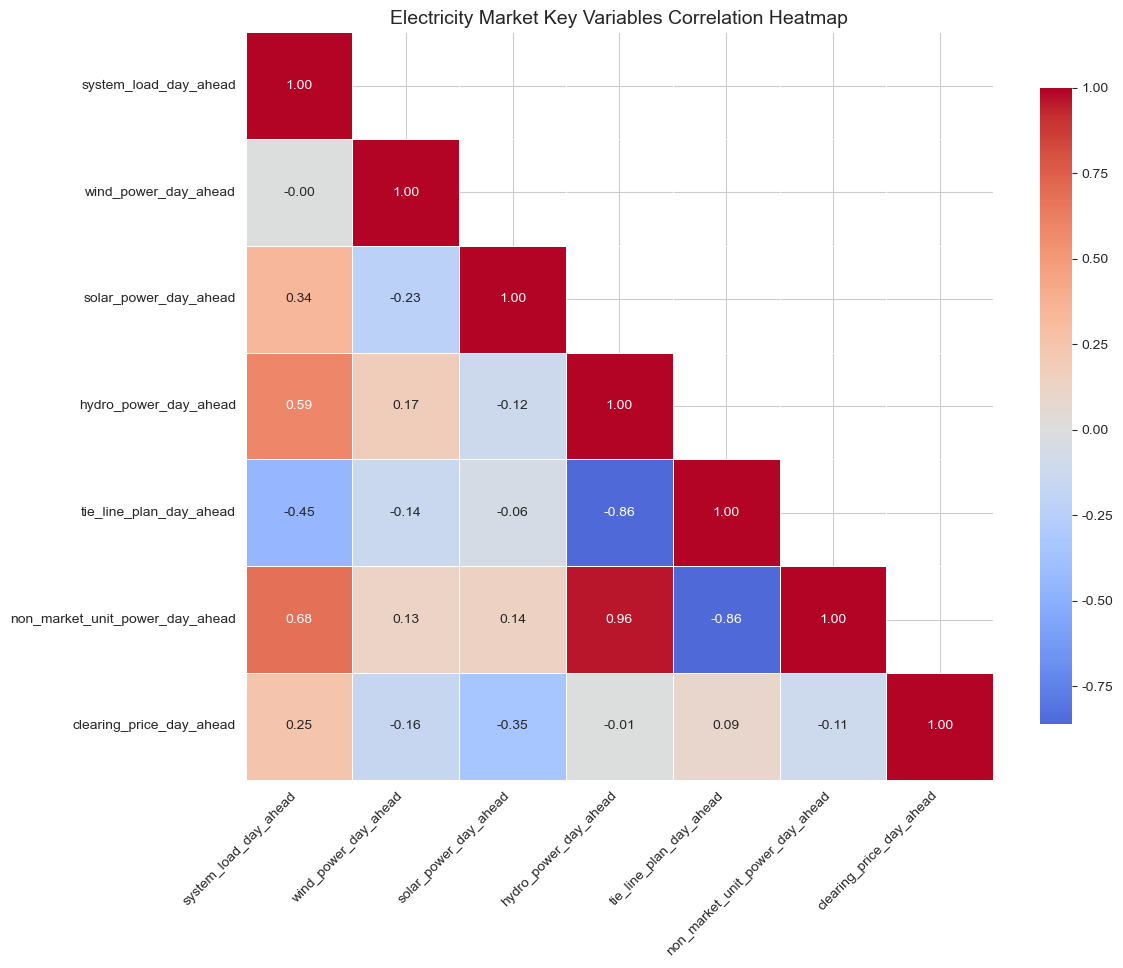

In [13]:
# 热力图 - 变量相关性分析
correlation_cols = ['system_load_day_ahead', 'wind_power_day_ahead', 'solar_power_day_ahead', 
                   'hydro_power_day_ahead', 'tie_line_plan_day_ahead', 
                   'non_market_unit_power_day_ahead', 'clearing_price_day_ahead']

corr_matrix = df_en[correlation_cols].corr()

plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, 
            mask=mask,          
            annot=True, 
            cmap='coolwarm', 
            center=0,
            square=True, 
            fmt='.2f', 
            cbar_kws={'shrink': .8},
            linewidths=0.5)      # 加网格线更清晰

plt.title('Electricity Market Key Variables Correlation Heatmap', fontsize=14)
plt.xticks(rotation=45, ha='right')  # X轴标签旋转，避免重叠
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

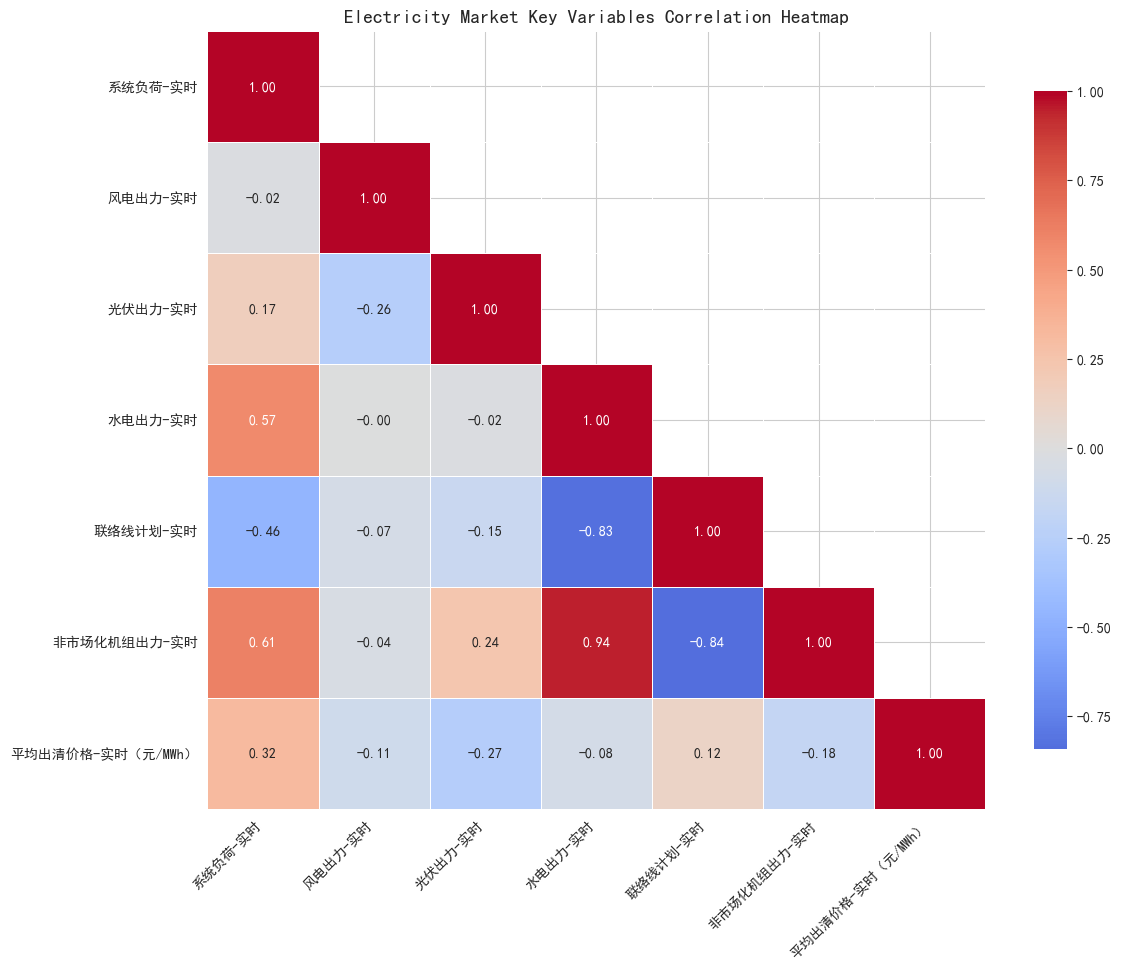

In [17]:
# 热力图 - 变量相关性分析
correlation_cols = ['系统负荷-实时', '风电出力-实时', '光伏出力-实时', 
                   '水电出力-实时', '联络线计划-实时', 
                   '非市场化机组出力-实时', '平均出清价格-实时（元/MWh）']

corr_matrix = df[correlation_cols].corr()

plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, 
            mask=mask,          
            annot=True, 
            cmap='coolwarm', 
            center=0,
            square=True, 
            fmt='.2f', 
            cbar_kws={'shrink': .8},
            linewidths=0.5)      # 加网格线更清晰

plt.title('Electricity Market Key Variables Correlation Heatmap', fontsize=14)
plt.xticks(rotation=45, ha='right')  # X轴标签旋转，避免重叠
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

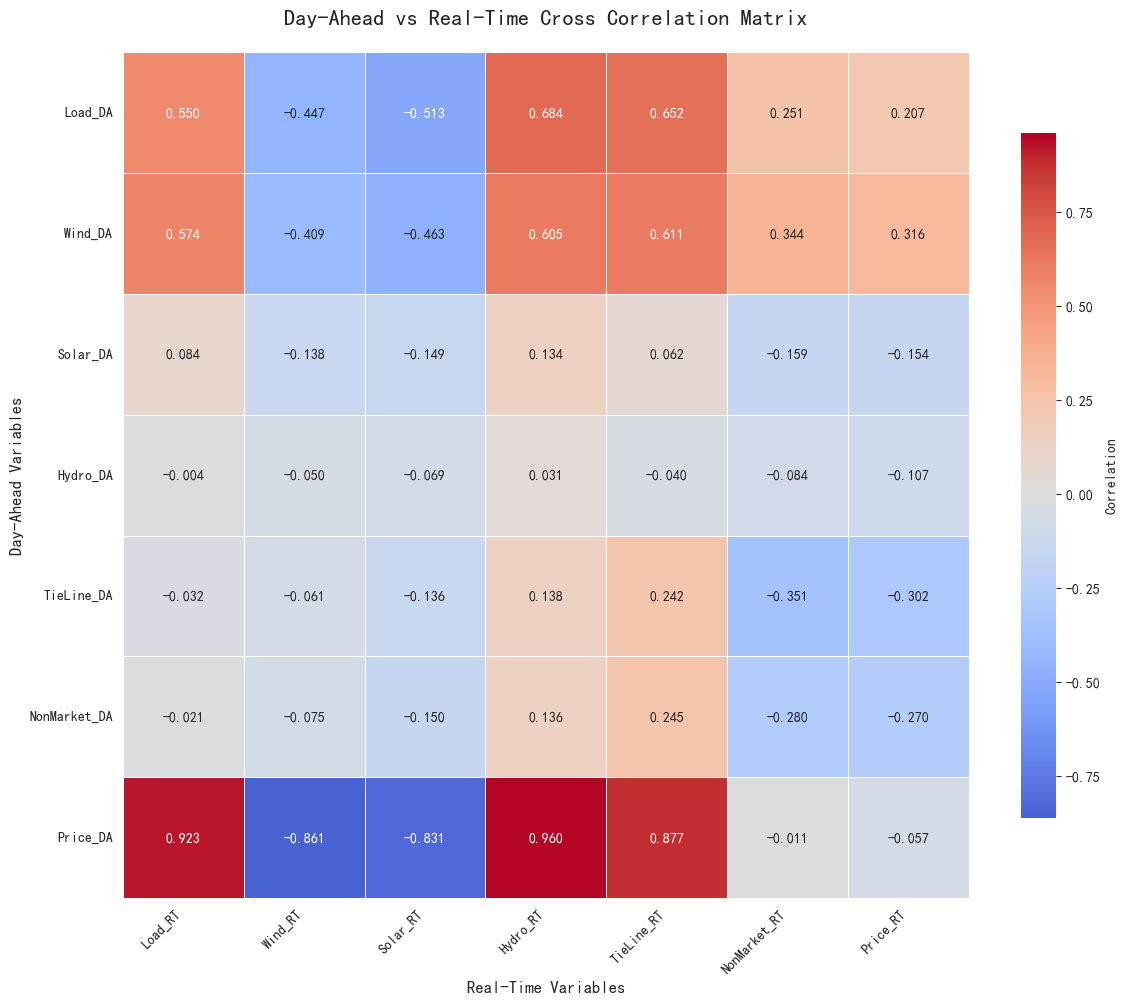


关键交叉相关性发现 (日前 vs 实时)

【同类型变量相关性】
  负荷: 0.5495
  风电: -0.4093
  光伏: -0.1489
  水电: 0.0311
  联络线: 0.2416
  非市场化机组: -0.2799
  价格: -0.0573

【日前价格 vs 实时变量】
  日前价格 vs Load_RT: 0.9226
  日前价格 vs Wind_RT: -0.8614
  日前价格 vs Solar_RT: -0.8309
  日前价格 vs Hydro_RT: 0.9605
  日前价格 vs TieLine_RT: 0.8767
  日前价格 vs NonMarket_RT: -0.0106
  日前价格 vs Price_RT: -0.0573

【实时价格 vs 日前变量】
  Load_DA vs 实时价格: 0.2074
  Wind_DA vs 实时价格: 0.3163
  Solar_DA vs 实时价格: -0.1541
  Hydro_DA vs 实时价格: -0.1067
  TieLine_DA vs 实时价格: -0.3023
  NonMarket_DA vs 实时价格: -0.2703
  Price_DA vs 实时价格: -0.0573


In [19]:
# ============ 日前 vs 实时 交叉相关性分析 ============

# 定义日前和实时变量
day_ahead_cols = ['系统负荷-日前', '风电出力-日前', '光伏出力-日前', 
                  '水电出力-日前', '联络线计划-日前', 
                  '非市场化机组出力-日前', '平均出清价格-日前（元/MWh）']

real_time_cols = ['系统负荷-实时', '风电出力-实时', '光伏出力-实时', 
                  '水电出力-实时', '联络线计划-实时', 
                  '非市场化机组出力-实时', '平均出清价格-实时（元/MWh）']

# 创建组合数据集进行交叉相关性计算
cross_corr_data = pd.DataFrame()
for da_col, rt_col in zip(day_ahead_cols, real_time_cols):
    cross_corr_data[da_col.replace('-日前', '_DA')] = df[da_col]
    cross_corr_data[rt_col.replace('-实时', '_RT')] = df[rt_col]

# 计算相关性矩阵
cross_corr_matrix = cross_corr_data.corr()

# 只保留日前vs实时的交叉部分（7x7的子矩阵）
cross_corr_subset = cross_corr_matrix.iloc[:7, 7:]

# 使用英文标签
row_labels = ['Load_DA', 'Wind_DA', 'Solar_DA', 'Hydro_DA', 'TieLine_DA', 'NonMarket_DA', 'Price_DA']
col_labels = ['Load_RT', 'Wind_RT', 'Solar_RT', 'Hydro_RT', 'TieLine_RT', 'NonMarket_RT', 'Price_RT']

cross_corr_subset.index = row_labels
cross_corr_subset.columns = col_labels

# 绘制交叉相关性热力图
plt.figure(figsize=(12, 10))
sns.heatmap(cross_corr_subset, 
            annot=True, 
            cmap='coolwarm', 
            center=0,
            square=True, 
            fmt='.3f', 
            cbar_kws={'shrink': .8, 'label': 'Correlation'},
            linewidths=0.5)

plt.title('Day-Ahead vs Real-Time Cross Correlation Matrix', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Real-Time Variables', fontsize=12)
plt.ylabel('Day-Ahead Variables', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 打印关键发现
print("\n" + "="*60)
print("关键交叉相关性发现 (日前 vs 实时)")
print("="*60)

# 对角线元素（同类型变量的日前-实时相关性）
print("\n【同类型变量相关性】")
for i, var in enumerate(['负荷', '风电', '光伏', '水电', '联络线', '非市场化机组', '价格']):
    corr_val = cross_corr_subset.iloc[i, i]
    print(f"  {var}: {corr_val:.4f}")

# 日前价格与其他实时变量的相关性
print("\n【日前价格 vs 实时变量】")
price_da_corr = cross_corr_subset.iloc[-1, :]
for col, val in price_da_corr.items():
    print(f"  日前价格 vs {col}: {val:.4f}")

# 实时价格与其他日前变量的相关性
print("\n【实时价格 vs 日前变量】")
price_rt_corr = cross_corr_subset.iloc[:, -1]
for idx, val in price_rt_corr.items():
    print(f"  {idx} vs 实时价格: {val:.4f}")

<Figure size 1200x1000 with 0 Axes>

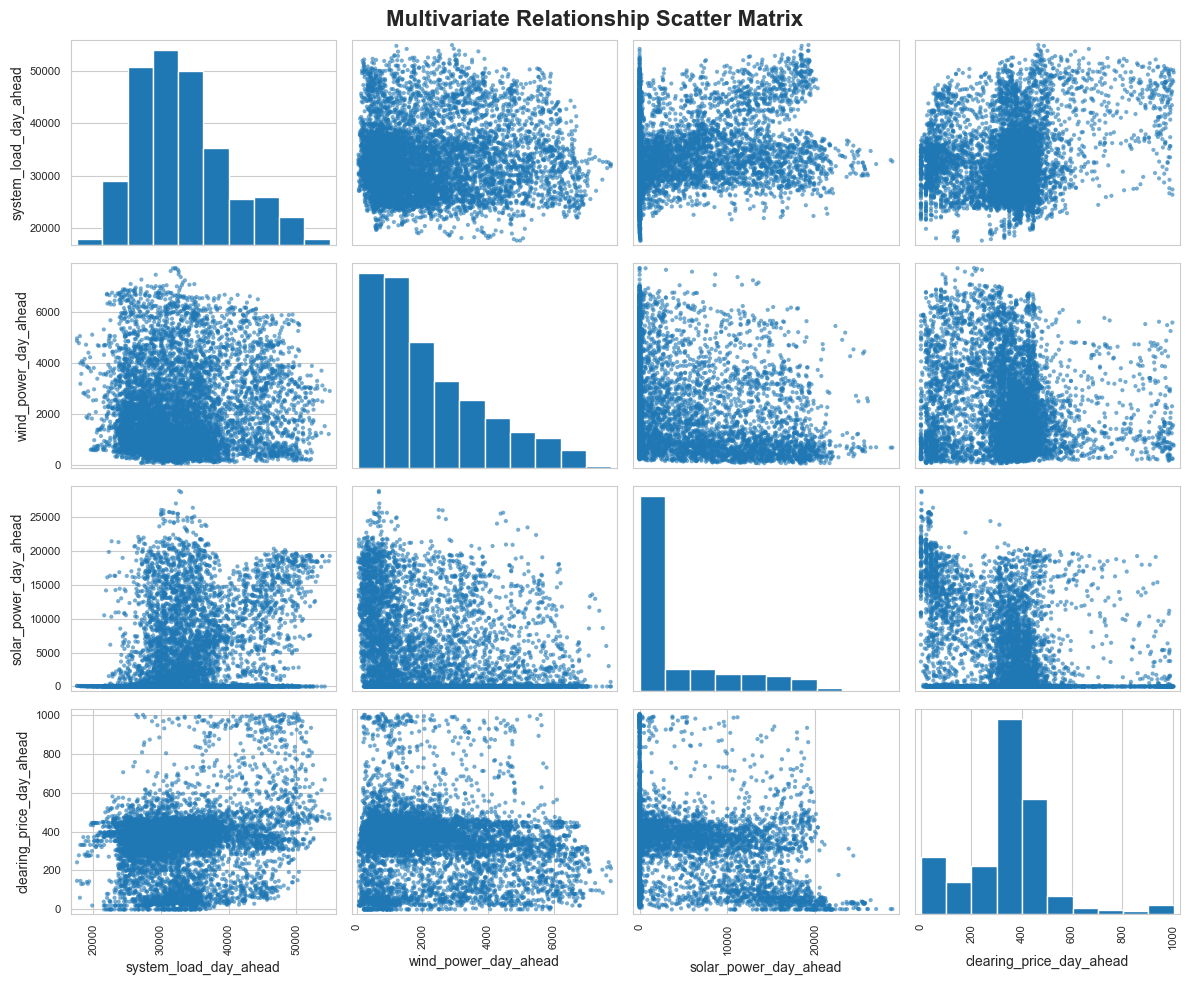

In [34]:
# 多变量散点图矩阵
# 选择关键变量进行散点图矩阵分析
scatter_cols = ['system_load_day_ahead', 'wind_power_day_ahead', 'solar_power_day_ahead', 'clearing_price_day_ahead']
scatter_df = df_en[scatter_cols].dropna()

from pandas.plotting import scatter_matrix

plt.figure(figsize=(12, 10))
scatter_matrix(scatter_df, alpha=0.6, figsize=(12, 10), diagonal='hist')
plt.suptitle('Multivariate Relationship Scatter Matrix', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### 7.2 特征重要性分析

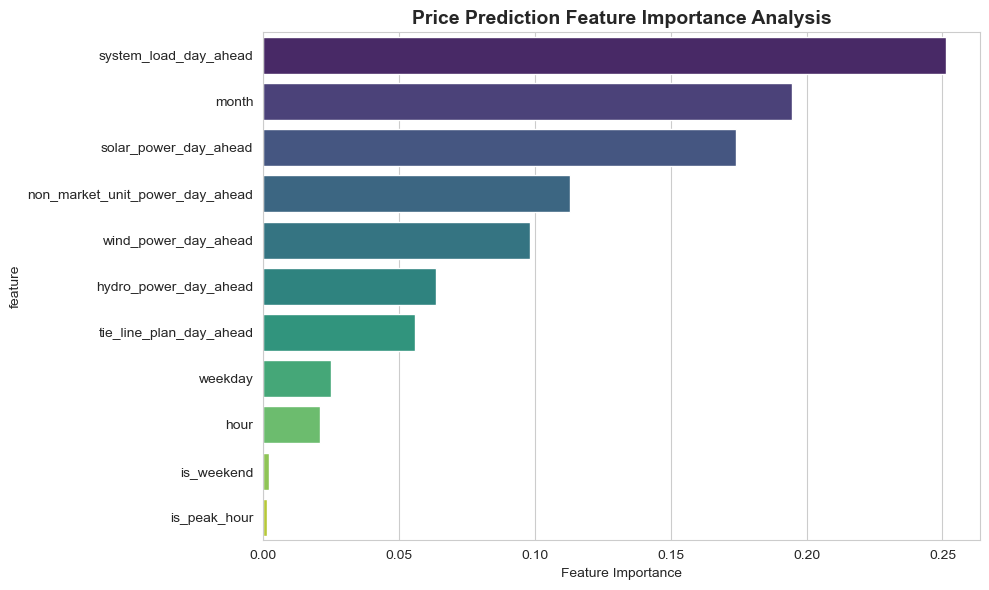

In [14]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 准备特征和目标变量
feature_cols = ['system_load_day_ahead', 'wind_power_day_ahead', 
                'solar_power_day_ahead', 'hydro_power_day_ahead',
                'tie_line_plan_day_ahead', 'non_market_unit_power_day_ahead',
                'hour', 'weekday', 'month', 'is_weekend', 'is_peak_hour']

# 同步清洗
xy = df_en[feature_cols + ['clearing_price_day_ahead']].dropna()
X = xy[feature_cols]
y = xy['clearing_price_day_ahead']

# 数据标准化
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 训练随机森林模型
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# 特征重要性可视化
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x='importance', y='feature', palette='viridis')
plt.title('Price Prediction Feature Importance Analysis', fontsize=14, fontweight='bold')
plt.xlabel('Feature Importance')
plt.tight_layout()
plt.show()

## 7. 异常值监测

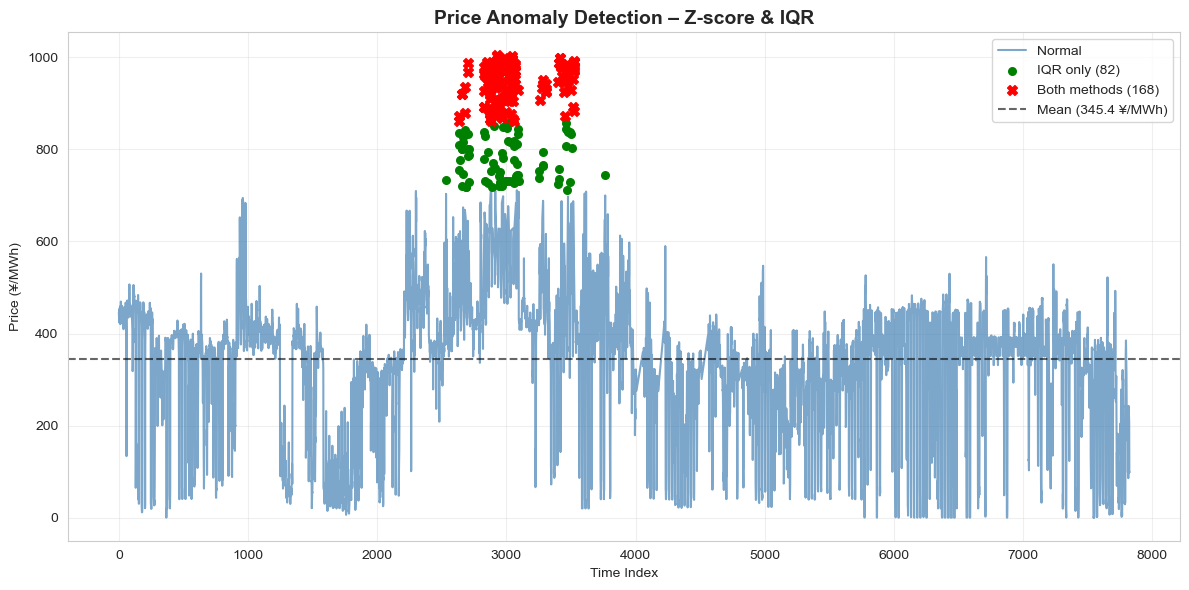

In [17]:
from scipy import stats

price_data = df_en['clearing_price_day_ahead'].dropna()

# ---------- Z-score ----------
z_scores = np.abs(stats.zscore(price_data))
z_thresh = 3
z_anom = price_data[z_scores > z_thresh]

# ---------- IQR ----------
q1 = price_data.quantile(0.25)
q3 = price_data.quantile(0.75)
iqr = q3 - q1
lower = q1 - 2 * iqr
upper = q3 + 2 * iqr
iqr_anom = price_data[(price_data < lower) | (price_data > upper)]

# ---------- 合并异常标签 ----------
anom_idx = set(z_anom.index) | set(iqr_anom.index)          # 并集
both_idx = set(z_anom.index) & set(iqr_anom.index)          # 交集
z_only   = set(z_anom.index) - both_idx
iqr_only = set(iqr_anom.index) - both_idx

# 为绘图准备
normal     = price_data[~price_data.index.isin(anom_idx)]
z_only_s   = price_data[price_data.index.isin(z_only)]
iqr_only_s = price_data[price_data.index.isin(iqr_only)]
both_s     = price_data[price_data.index.isin(both_idx)]

# ---------- 可视化 ----------
plt.figure(figsize=(12, 6))
plt.plot(normal.index, normal.values, alpha=0.7, label='Normal', color='steelblue')
if len(z_only_s):
    plt.scatter(z_only_s.index, z_only_s.values, color='orange', s=30,
                label=f'Z-score only ({len(z_only)})', zorder=5)
if len(iqr_only_s):
    plt.scatter(iqr_only_s.index, iqr_only_s.values, color='green', s=30,
                label=f'IQR only ({len(iqr_only)})', zorder=5)
if len(both_s):
    plt.scatter(both_s.index, both_s.values, color='red', s=50, marker='X',
                label=f'Both methods ({len(both_s)})', zorder=6)

plt.axhline(y=price_data.mean(), color='black', linestyle='--', alpha=0.6,
            label=f'Mean ({price_data.mean():.1f} ¥/MWh)')
plt.title('Price Anomaly Detection – Z-score & IQR', fontsize=14, fontweight='bold')
plt.xlabel('Time Index')
plt.ylabel('Price (¥/MWh)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. 数据洞察

In [36]:
# 生成数据洞察总结
print("=== Data Insights Summary ===\n")

# 价格洞察
price_stats = df_en['clearing_price_day_ahead'].describe()
print("1. Price Features:")
print(f"   • Average Price: {price_stats['mean']:.2f} CNY/MWh")
print(f"   • Price Range: {price_stats['min']:.2f} - {price_stats['max']:.2f} CNY/MWh")
print(f"   • Price Volatility: Standard Deviation {price_stats['std']:.2f} CNY/MWh")

# 负荷洞察
load_stats = df_en['system_load_day_ahead'].describe()
print(f"\n2. Load Features:")
print(f"   • Average Load: {load_stats['mean']:.0f} MW")
print(f"   • Load Range: {load_stats['min']:.0f} - {load_stats['max']:.0f} MW")

# 新能源洞察
wind_stats = df_en['wind_power_day_ahead'].describe()
solar_stats = df_en['solar_power_day_ahead'].describe()
print(f"\n3. Renewable Energy Features:")
print(f"   • Average Wind Power: {wind_stats['mean']:.0f} MW")
print(f"   • Average Solar Power: {solar_stats['mean']:.0f} MW")

# 时间模式洞察
hourly_pattern = df_en.groupby('hour')['clearing_price_day_ahead'].mean()
peak_hour = hourly_pattern.idxmax()
peak_price = hourly_pattern.max()
print(f"\n4. Time Patterns:")
print(f"   • Peak Price Hour: {peak_hour}h ({peak_price:.2f} CNY/MWh)")
print(f"   • Data Time Range: {df_en['date'].min().strftime('%Y-%m-%d')} to {df_en['date'].max().strftime('%Y-%m-%d')}")

# 数据质量洞察
missing_total = df_en.isnull().sum().sum()
missing_percent = (missing_total / (df_en.shape[0] * df_en.shape[1])) * 100
print(f"\n5. Data Quality:")
print(f"   • Total Missing Value Percentage: {missing_percent:.2f}%")
print(f"   • Data Integrity: {'Good' if missing_percent < 5 else 'Needs Attention'}")

=== Data Insights Summary ===

1. Price Features:
   • Average Price: 345.45 CNY/MWh
   • Price Range: 0.00 - 1004.26 CNY/MWh
   • Price Volatility: Standard Deviation 171.68 CNY/MWh

2. Load Features:
   • Average Load: 32940 MW
   • Load Range: 17590 - 54911 MW

3. Renewable Energy Features:
   • Average Wind Power: 2174 MW
   • Average Solar Power: 4181 MW

4. Time Patterns:
   • Peak Price Hour: 20h (422.21 CNY/MWh)
   • Data Time Range: 2024-04-16 to 2025-03-27

5. Data Quality:
   • Total Missing Value Percentage: 2.97%
   • Data Integrity: Good


In [38]:
# 保存关键统计结果
analysis_results = {
    'Basic Information': {
        'Total Records': len(df_en),
        'Time Range': f"{df_en['date'].min().strftime('%Y-%m-%d')} to {df_en['date'].max().strftime('%Y-%m-%d')}",
        'Total Days': df_en['date'].nunique(),
        'Variable Count': len(df_en.columns)
    },
    'Price Statistics': df_en['clearing_price_day_ahead'].describe().to_dict(),
    'Load Statistics': df_en['system_load_day_ahead'].describe().to_dict(),
    'Correlation Analysis': df_en[correlation_cols].corr().to_dict()
}

# 可以将结果保存为JSON文件
import json
with open('data_analysis_results.json', 'w', encoding='utf-8') as f:
    json.dump(analysis_results, f, ensure_ascii=False, indent=2)

print("Analysis results saved to 'data_analysis_results.json'")

Analysis results saved to 'data_analysis_results.json'
